# Bodrum Hotel & Destination Intelligence
## 12 - Şikayetvar All-Hotels Complaint Audit & Cleaning
### Negative Customer Voice Corpus — Veri Kalitesi, Eşleşme Doğrulama ve Temiz Corpus Hazırlama

Bu notebook Şikayetvar all-hotels scraping çıktısını audit eder, yalnız complaint-level kesin
eşleşmeleri ana corpusa alır ve sonraki EDA/NLP aşamaları için izlenebilir processed veri üretir.
Yeni scraping, EDA, sentiment, topic, aspect veya makine öğrenmesi yapılmaz.

> **Metodolojik uyarı:** Şikayetvar normal müşteri yorumu dataset'i değildir; bir **negative
> customer voice / complaint corpus** olarak ele alınmalıdır. Bu veri customer satisfaction
> ölçümü değildir, tüm müşterileri temsil etmez, complaint count gerçek complaint rate veya hotel
> quality score değildir. Google reviews ile aynı sampling process'e sahip değildir.

**Ana corpus kuralı:** Hotel mapping statüsü ile complaint-level entity statüsü farklıdır. Ana
clean corpus yalnız gerçek verideki `COMPLAINT_MATCHED` statüsünü kabul eder;
`COMPLAINT_REVIEW_REQUIRED` ayrı tutulur ve otomatik olarak matched yapılmaz.


## 01. Amaç ve metodolojik çerçeve

Audit beş soruya cevap verir:

1. Complaint ve reply kayıtlarının anahtarları, şemaları ve referential integrity'si güvenilir mi?
2. Hangi complaint'ler ana corpusa girebilir, hangileri manual review gerektirir?
3. Raw → clean dönüşümünde yalnız hangi teknik standardizasyonlar yapıldı?
4. Missing, tarih, numeric, text ve response/reply kalite sorunları nelerdir?
5. Veri, hacim/tema yorumu yapmadan Notebook 13 EDA aşamasına hazır mı?

Raw metinler korunur. Minimal clean alanlarda yalnız Unicode/HTML/whitespace/control-character
standardizasyonu yapılır; stemming, lemmatization, stopword/punctuation/emoji/negation removal,
spelling correction veya imputasyon yapılmaz.


In [1]:
from pathlib import Path
import hashlib
import re
import sys

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from bodrum_intelligence.sikayetvar_cleaning import (
    clean_raw_text_minimal,
    derive_reply_metrics,
    exact_duplicate_audit,
    near_duplicate_candidates,
    normalize_for_duplicate,
    prepare_complaints,
    prepare_replies,
)

RAW_DIR = PROJECT_ROOT / "data/raw/sikayetvar"
PROCESSED_DIR = PROJECT_ROOT / "data/processed"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures/sikayetvar_audit_cleaning"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

paths = {
    "hotel_mapping": RAW_DIR / "sikayetvar_hotel_mapping.csv",
    "mapping_candidates": RAW_DIR / "sikayetvar_mapping_candidates.csv",
    "complaint_links": RAW_DIR / "sikayetvar_all_complaint_links.csv",
    "complaints_raw": RAW_DIR / "sikayetvar_all_hotels_complaints_raw.csv",
    "replies_raw": RAW_DIR / "sikayetvar_all_hotels_replies_raw.csv",
    "scrape_status": RAW_DIR / "sikayetvar_scrape_status_all_hotels.csv",
    "hotel_master": PROCESSED_DIR / "hotels_enriched.csv",
    "scraper_summary": REPORTS_DIR / "sikayetvar_all_hotels_scraping_summary.txt",
}
missing = [str(path.relative_to(PROJECT_ROOT)) for path in paths.values() if not path.exists()]
assert not missing, f"Eksik zorunlu girdi: {missing}"

raw_csv_paths = [path for key, path in paths.items() if key not in {"hotel_master", "scraper_summary"}]
raw_hashes_before = {path.name: hashlib.sha256(path.read_bytes()).hexdigest() for path in raw_csv_paths}

hotel_mapping = pd.read_csv(paths["hotel_mapping"], dtype=str)
mapping_candidates = pd.read_csv(paths["mapping_candidates"], dtype=str)
complaint_links = pd.read_csv(paths["complaint_links"], dtype=str)
complaints_raw = pd.read_csv(paths["complaints_raw"], dtype=str)
replies_raw = pd.read_csv(paths["replies_raw"], dtype=str)
scrape_status = pd.read_csv(paths["scrape_status"], dtype=str)
hotel_master = pd.read_csv(paths["hotel_master"])

pd.set_option("display.max_columns", 40)
pd.set_option("display.max_colwidth", 100)
print("Raw complaints:", complaints_raw.shape, "| Raw replies:", replies_raw.shape, "| Hotel mapping:", hotel_mapping.shape)


Raw complaints: (248, 30) | Raw replies: (97, 8) | Hotel mapping: (192, 16)


## 02. Input inventory

In [2]:
inventory_specs = [
    ("hotel_mapping", paths["hotel_mapping"], "hotel mapping", "hotel_id", "match_status", "Hotel-level discovery/mapping universe"),
    ("mapping_candidates", paths["mapping_candidates"], "mapping candidate", "hotel_id + candidate_url", "match_method", "Candidate evidence; not clean-corpus authority"),
    ("complaint_links", paths["complaint_links"], "complaint link", "hotel_id + canonical_complaint_url", "entity_match_status", "Discovered complaint URLs"),
    ("complaints_raw", paths["complaints_raw"], "complaint", "canonical_complaint_url", "entity_match_status", "Primary raw complaint corpus"),
    ("replies_raw", paths["replies_raw"], "reply", "generated reply_id", "reply_author_type", "Raw reply corpus"),
    ("scrape_status", paths["scrape_status"], "hotel scrape status", "hotel_id", "scrape_status", "Detail collection reconciliation"),
    ("hotel_master", paths["hotel_master"], "hotel", "hotel_id", "official_match_status", "Metadata enrichment; never entity authority"),
]
loaded = {
    "hotel_mapping": hotel_mapping, "mapping_candidates": mapping_candidates,
    "complaint_links": complaint_links, "complaints_raw": complaints_raw,
    "replies_raw": replies_raw, "scrape_status": scrape_status, "hotel_master": hotel_master,
}
input_inventory = pd.DataFrame([
    {
        "dataset_name": name,
        "path": str(path.relative_to(PROJECT_ROOT)),
        "grain": grain,
        "row_count": len(loaded[name]),
        "column_count": loaded[name].shape[1],
        "primary_key": primary_key,
        "main_status_column": status,
        "role_in_notebook": role,
    }
    for name, path, grain, primary_key, status, role in inventory_specs
])
display(input_inventory)
display(Markdown(
    "**Raw immutability:** Altı raw CSV'nin SHA-256 özeti çalıştırma başında alındı. Final hücresinde "
    "aynı dosyalar yeniden hash'lenerek değişmedikleri doğrulanacaktır."
))


,dataset_name,path,grain,row_count,column_count,primary_key,main_status_column,role_in_notebook
0,hotel_mapping,data/raw/sikayetvar/sikayetvar_hotel_mapping.csv,hotel mapping,192,16,hotel_id,match_status,Hotel-level discovery/mapping universe
1,mapping_candidates,data/raw/sikayetvar/sikayetvar_mapping_candidates.csv,mapping candidate,141,20,hotel_id + candidate_url,match_method,Candidate evidence; not clean-corpus authority
2,complaint_links,data/raw/sikayetvar/sikayetvar_all_complaint_links.csv,complaint link,248,11,hotel_id + canonical_complaint_url,entity_match_status,Discovered complaint URLs
3,complaints_raw,data/raw/sikayetvar/sikayetvar_all_hotels_complaints_raw.csv,complaint,248,30,canonical_complaint_url,entity_match_status,Primary raw complaint corpus
4,replies_raw,data/raw/sikayetvar/sikayetvar_all_hotels_replies_raw.csv,reply,97,8,generated reply_id,reply_author_type,Raw reply corpus
5,scrape_status,data/raw/sikayetvar/sikayetvar_scrape_status_all_hotels.csv,hotel scrape status,34,16,hotel_id,scrape_status,Detail collection reconciliation
6,hotel_master,data/processed/hotels_enriched.csv,hotel,192,46,hotel_id,official_match_status,Metadata enrichment; never entity authority


**Raw immutability:** Altı raw CSV'nin SHA-256 özeti çalıştırma başında alındı. Final hücresinde aynı dosyalar yeniden hash'lenerek değişmedikleri doğrulanacaktır.

## 03. Complaint schema audit

In [3]:
expected_roles = {
    "complaint_id": "complaint identifier", "complaint_url": "source URL",
    "canonical_complaint_url": "preferred dedupe/join key", "hotel_id": "project hotel join key",
    "hotel_name": "raw mapped hotel label", "area": "raw mapped area",
    "sikayetvar_company_name": "platform company label", "complaint_title": "raw title",
    "complaint_text": "raw complaint body", "complaint_date_raw": "raw displayed date",
    "view_count": "raw engagement count", "support_count": "raw support count; missing is not zero",
    "category": "optional platform category", "product_name": "optional product label",
    "company_response_exists": "raw response-presence flag", "company_response_date": "raw response date",
    "company_response_text": "raw company response", "progress_exists": "raw progress-presence flag",
    "progress_date": "raw progress date", "progress_text": "raw progress text",
    "user_reply_count": "raw user reply count", "entity_match_status": "complaint-level corpus authority",
    "entity_match_score": "optional entity score", "entity_match_reason": "entity decision evidence",
    "source_page": "discovery page", "collected_at": "collection timestamp",
}
schema_audit = pd.DataFrame([
    {
        "column_name": column,
        "dtype": str(complaints_raw[column].dtype),
        "non_null_count": int(complaints_raw[column].notna().sum()),
        "missing_count": int(complaints_raw[column].isna().sum()),
        "missing_pct": 100 * complaints_raw[column].isna().mean(),
        "unique_count": int(complaints_raw[column].nunique(dropna=True)),
        "expected_role": expected_roles.get(column, "source-specific / duplicate extraction field"),
        "notes": "Preserve raw; do not overwrite" if column in expected_roles else "Inspect before downstream use",
    }
    for column in complaints_raw.columns
])
schema_audit.to_csv(REPORTS_DIR / "sikayetvar_complaint_schema_audit.csv", index=False)
display(pd.DataFrame([
    ("row_count", len(complaints_raw)),
    ("column_count", complaints_raw.shape[1]),
    ("memory_usage_mb", complaints_raw.memory_usage(deep=True).sum() / 1024**2),
], columns=["Metric", "Value"]))
display(schema_audit)


,Metric,Value
0,row_count,248.000000
1,column_count,30.000000
2,memory_usage_mb,1.305184


,column_name,dtype,non_null_count,missing_count,missing_pct,unique_count,expected_role,notes
0,complaint_id,object,248,0,0.000000,245,complaint identifier,Preserve raw; do not overwrite
1,complaint_url,object,248,0,0.000000,245,source URL,Preserve raw; do not overwrite
2,canonical_complaint_url,object,248,0,0.000000,245,preferred dedupe/join key,Preserve raw; do not overwrite
3,hotel_id,object,248,0,0.000000,34,project hotel join key,Preserve raw; do not overwrite
4,hotel_name,object,248,0,0.000000,34,raw mapped hotel label,Preserve raw; do not overwrite
5,area,object,248,0,0.000000,12,raw mapped area,Preserve raw; do not overwrite
6,sikayetvar_company_name,object,248,0,0.000000,34,platform company label,Preserve raw; do not overwrite
7,complaint_id.1,object,248,0,0.000000,245,source-specific / duplicate extraction field,Inspect before downstream use
8,complaint_url.1,object,248,0,0.000000,245,source-specific / duplicate extraction field,Inspect before downstream use
9,complaint_title,object,248,0,0.000000,243,raw title,Preserve raw; do not overwrite


### Bölüm Sonucu

Raw complaint tablosu 30 kolon taşır. `complaint_id.1` ve `complaint_url.1` gibi extraction
tekrarları source-specific alan olarak korunur; canonical URL ana dedupe/join anahtarıdır. Hiçbir
raw kolon overwrite edilmez.


## 04. Entity status audit

In [4]:
complaint_entity_status = (
    complaints_raw["entity_match_status"].fillna("MISSING").value_counts(dropna=False)
    .rename_axis("entity_match_status").reset_index(name="complaint_count")
)
complaint_entity_status["share_pct"] = 100 * complaint_entity_status["complaint_count"] / len(complaints_raw)
complaint_entity_status.to_csv(REPORTS_DIR / "sikayetvar_complaint_entity_status_audit.csv", index=False)

hotel_mapping_status = (
    hotel_mapping["match_status"].fillna("MISSING").value_counts(dropna=False)
    .rename_axis("match_status").reset_index(name="hotel_count")
)
hotel_mapping_status["share_pct"] = 100 * hotel_mapping_status["hotel_count"] / len(hotel_mapping)
hotel_mapping_status.to_csv(REPORTS_DIR / "sikayetvar_hotel_mapping_status_audit.csv", index=False)

manual_columns = [
    "complaint_id", "canonical_complaint_url", "hotel_id", "hotel_name", "area",
    "complaint_title", "complaint_text", "entity_match_status", "entity_match_score",
    "entity_match_reason", "source_page",
]
complaints_manual_review = complaints_raw.loc[
    complaints_raw["entity_match_status"].eq("COMPLAINT_REVIEW_REQUIRED"), manual_columns
].copy()
complaints_manual_review.to_csv(REPORTS_DIR / "sikayetvar_complaints_manual_review.csv", index=False)
excluded_wrong_property = complaints_raw.loc[
    complaints_raw["entity_match_status"].isin(["COMPLAINT_EXCLUDED_OTHER_PROPERTY", "EXCLUDED_OTHER_PROPERTY"]),
    manual_columns,
].copy()
excluded_wrong_property.to_csv(REPORTS_DIR / "sikayetvar_complaints_excluded_wrong_property.csv", index=False)

display(Markdown("#### Complaint-level entity statüsü — clean corpus authority"))
display(complaint_entity_status)
display(Markdown("#### Hotel-level mapping statüsü — discovery coverage"))
display(hotel_mapping_status)


#### Complaint-level entity statüsü — clean corpus authority

,entity_match_status,complaint_count,share_pct
0,COMPLAINT_MATCHED,236,95.16129
1,COMPLAINT_REVIEW_REQUIRED,12,4.83871


#### Hotel-level mapping statüsü — discovery coverage

,match_status,hotel_count,share_pct
0,NOT_FOUND,104,54.166667
1,REVIEW_REQUIRED,43,22.395833
2,FOUND_EXACT,31,16.145833
3,PAGE_FOUND_NO_COMPLAINT,12,6.250000
4,AMBIGUOUS,1,0.520833
5,FOUND_HIGH_CONFIDENCE,1,0.520833


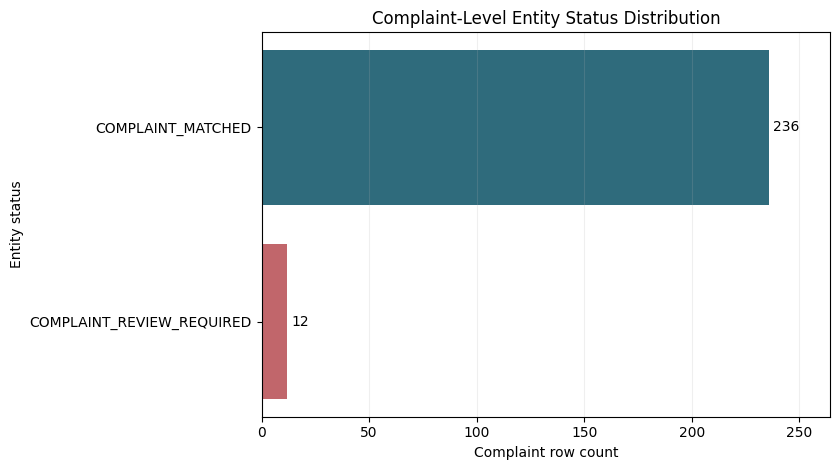

In [5]:
fig, ax = plt.subplots(figsize=(8.5, 4.8))
plot_status = complaint_entity_status.sort_values("complaint_count")
ax.barh(plot_status["entity_match_status"], plot_status["complaint_count"], color=["#C1666B", "#2F6B7C"])
for index, value in enumerate(plot_status["complaint_count"]):
    ax.text(value + 2, index, f"{value}", va="center")
ax.set(title="Complaint-Level Entity Status Distribution", xlabel="Complaint row count", ylabel="Entity status")
ax.set_xlim(0, plot_status["complaint_count"].max() * 1.12)
ax.grid(axis="x", alpha=0.2)
fig.tight_layout(); fig.savefig(FIGURES_DIR / "01_entity_status_distribution.png", dpi=160, bbox_inches="tight"); plt.show(); plt.close(fig)


**Ne gösteriyor?** Raw complaint satırlarının complaint-level entity kararını gösterir.

**Neden audit için önemli?** Ana corpusun hangi statüden kurulacağını doğrudan belirler; hotel
mapping statüsüyle karıştırılmasını engeller.

**Limitation:** Statü dağılımı mapping doğruluğunun tek başına kanıtı değildir; karar gerekçeleri ve
manual-review kayıtları ayrıca korunur.


## 05. Duplicate audit

In [6]:
key_rows = []
for key_name in ["complaint_id", "canonical_complaint_url", "complaint_url"]:
    series = complaints_raw[key_name]
    key_rows.append({
        "key_name": key_name,
        "row_count": len(series),
        "non_null_count": int(series.notna().sum()),
        "missing_count": int(series.isna().sum()),
        "unique_count": int(series.nunique(dropna=True)),
        "duplicate_excess_count": int(series.notna().sum() - series.nunique(dropna=True)),
        "is_unique": bool(series.dropna().is_unique),
        "preferred_dedupe_key": key_name == "canonical_complaint_url",
    })
complaint_key_audit = pd.DataFrame(key_rows)
complaint_key_audit.to_csv(REPORTS_DIR / "sikayetvar_complaint_key_audit.csv", index=False)

exact_duplicates = exact_duplicate_audit(complaints_raw)
exact_duplicates.to_csv(REPORTS_DIR / "sikayetvar_exact_duplicate_audit.csv", index=False)
canonical_duplicate_excess = int(
    complaints_raw["canonical_complaint_url"].notna().sum()
    - complaints_raw["canonical_complaint_url"].nunique(dropna=True)
)

complaints_prepared, very_short_threshold = prepare_complaints(complaints_raw)
near_duplicates = near_duplicate_candidates(complaints_prepared, threshold=0.94)
near_duplicates.to_csv(REPORTS_DIR / "sikayetvar_near_duplicate_candidates.csv", index=False)

duplicate_canonical_urls = set(
    complaints_raw.loc[
        complaints_raw["canonical_complaint_url"].duplicated(keep=False), "canonical_complaint_url"
    ].dropna()
)
near_urls = set(near_duplicates.get("canonical_url_a", pd.Series(dtype=str)).dropna()) | set(
    near_duplicates.get("canonical_url_b", pd.Series(dtype=str)).dropna()
)
complaints_prepared["potential_duplicate_flag"] = complaints_prepared["canonical_complaint_url"].isin(
    duplicate_canonical_urls | near_urls
)
complaints_prepared["possible_duplicate_flag"] = complaints_prepared["potential_duplicate_flag"]

display(complaint_key_audit)
display(Markdown(
    f"**Canonical duplicate excess:** {canonical_duplicate_excess}. Bunlar üç URL'nin bir kesin "
    "eşleşmiş ve bir review-required otele çapraz atanmasından oluşur. Kesin eşleşmiş satır ana "
    "corpusta korunur; review-required satır manual review dosyasında kalır."
))
display(exact_duplicates)
display(Markdown(f"**Near-duplicate candidate:** {len(near_duplicates)}; otomatik silme yapılmadı."))


,key_name,row_count,non_null_count,missing_count,unique_count,duplicate_excess_count,is_unique,preferred_dedupe_key
0,complaint_id,248,248,0,245,3,False,False
1,canonical_complaint_url,248,248,0,245,3,False,True
2,complaint_url,248,248,0,245,3,False,False


**Canonical duplicate excess:** 3. Bunlar üç URL'nin bir kesin eşleşmiş ve bir review-required otele çapraz atanmasından oluşur. Kesin eşleşmiş satır ana corpusta korunur; review-required satır manual review dosyasında kalır.

,duplicate_type,duplicate_key,row_index,complaint_id,canonical_complaint_url,hotel_id,hotel_name,entity_match_status,occurrence_rank
0,canonical_complaint_url,https://www.sikayetvar.com/selectum-hotels/selectum-collection-bodrumda-valesiz-giris-ve-koordin...,235,selectum-collection-bodrumda-valesiz-giris-ve-koordinasyon-sorunlari,https://www.sikayetvar.com/selectum-hotels/selectum-collection-bodrumda-valesiz-giris-ve-koordin...,BOD068,Selectum Colours Bodrum,COMPLAINT_REVIEW_REQUIRED,1
1,canonical_complaint_url,https://www.sikayetvar.com/selectum-hotels/selectum-collection-bodrumda-valesiz-giris-ve-koordin...,236,selectum-collection-bodrumda-valesiz-giris-ve-koordinasyon-sorunlari,https://www.sikayetvar.com/selectum-hotels/selectum-collection-bodrumda-valesiz-giris-ve-koordin...,BOD012,Selectum Collection Bodrum,COMPLAINT_MATCHED,2
2,canonical_complaint_url,https://www.sikayetvar.com/selectum-hotels/selectum-hotels-odalar-eski-temizlik-yetersiz-yemek-k...,237,selectum-hotels-odalar-eski-temizlik-yetersiz-yemek-kalitesi-dusuk-ve-yerli-misafirlere-ayrimcilik,https://www.sikayetvar.com/selectum-hotels/selectum-hotels-odalar-eski-temizlik-yetersiz-yemek-k...,BOD068,Selectum Colours Bodrum,COMPLAINT_REVIEW_REQUIRED,1
3,canonical_complaint_url,https://www.sikayetvar.com/selectum-hotels/selectum-hotels-odalar-eski-temizlik-yetersiz-yemek-k...,238,selectum-hotels-odalar-eski-temizlik-yetersiz-yemek-kalitesi-dusuk-ve-yerli-misafirlere-ayrimcilik,https://www.sikayetvar.com/selectum-hotels/selectum-hotels-odalar-eski-temizlik-yetersiz-yemek-k...,BOD012,Selectum Collection Bodrum,COMPLAINT_MATCHED,2
4,canonical_complaint_url,https://www.sikayetvar.com/selectum-hotels/selectum-collection-hotel-bodrum-sorun-yasama,242,selectum-collection-hotel-bodrum-sorun-yasama,https://www.sikayetvar.com/selectum-hotels/selectum-collection-hotel-bodrum-sorun-yasama,BOD068,Selectum Colours Bodrum,COMPLAINT_REVIEW_REQUIRED,1
5,canonical_complaint_url,https://www.sikayetvar.com/selectum-hotels/selectum-collection-hotel-bodrum-sorun-yasama,243,selectum-collection-hotel-bodrum-sorun-yasama,https://www.sikayetvar.com/selectum-hotels/selectum-collection-hotel-bodrum-sorun-yasama,BOD012,Selectum Collection Bodrum,COMPLAINT_MATCHED,2
6,complaint_id,selectum-collection-bodrumda-valesiz-giris-ve-koordinasyon-sorunlari,235,selectum-collection-bodrumda-valesiz-giris-ve-koordinasyon-sorunlari,https://www.sikayetvar.com/selectum-hotels/selectum-collection-bodrumda-valesiz-giris-ve-koordin...,BOD068,Selectum Colours Bodrum,COMPLAINT_REVIEW_REQUIRED,1
7,complaint_id,selectum-collection-bodrumda-valesiz-giris-ve-koordinasyon-sorunlari,236,selectum-collection-bodrumda-valesiz-giris-ve-koordinasyon-sorunlari,https://www.sikayetvar.com/selectum-hotels/selectum-collection-bodrumda-valesiz-giris-ve-koordin...,BOD012,Selectum Collection Bodrum,COMPLAINT_MATCHED,2
8,complaint_id,selectum-hotels-odalar-eski-temizlik-yetersiz-yemek-kalitesi-dusuk-ve-yerli-misafirlere-ayrimcilik,237,selectum-hotels-odalar-eski-temizlik-yetersiz-yemek-kalitesi-dusuk-ve-yerli-misafirlere-ayrimcilik,https://www.sikayetvar.com/selectum-hotels/selectum-hotels-odalar-eski-temizlik-yetersiz-yemek-k...,BOD068,Selectum Colours Bodrum,COMPLAINT_REVIEW_REQUIRED,1
9,complaint_id,selectum-hotels-odalar-eski-temizlik-yetersiz-yemek-kalitesi-dusuk-ve-yerli-misafirlere-ayrimcilik,238,selectum-hotels-odalar-eski-temizlik-yetersiz-yemek-kalitesi-dusuk-ve-yerli-misafirlere-ayrimcilik,https://www.sikayetvar.com/selectum-hotels/selectum-hotels-odalar-eski-temizlik-yetersiz-yemek-k...,BOD012,Selectum Collection Bodrum,COMPLAINT_MATCHED,2


**Near-duplicate candidate:** 0; otomatik silme yapılmadı.

### Bölüm Sonucu

Canonical URL tercih edilen dedupe anahtarıdır. Raw veri değişmez; clean corpus önce kesin entity
statüsüne filtrelenir, sonra canonical URL benzersizliği zorunlu tutulur. Similarity yalnız review
flag'i üretir ve otomatik drop nedeni değildir.


## 06. Missing value audit

In [7]:
missing_values = pd.DataFrame({
    "column_name": complaints_raw.columns,
    "missing_count": [int(complaints_raw[column].isna().sum()) for column in complaints_raw.columns],
    "missing_pct": [100 * complaints_raw[column].isna().mean() for column in complaints_raw.columns],
    "non_null_count": [int(complaints_raw[column].notna().sum()) for column in complaints_raw.columns],
}).sort_values(["missing_count", "column_name"], ascending=[False, True])
missing_values.to_csv(REPORTS_DIR / "sikayetvar_complaint_missing_values.csv", index=False)
focus_missing = missing_values.loc[missing_values["column_name"].isin([
    "complaint_title", "complaint_text", "complaint_date_raw", "view_count", "support_count",
    "company_response_text", "progress_text", "category", "product_name",
])]
display(focus_missing)
display(Markdown(
    "`support_count` missing değerleri **zero değildir** ve `support_count_numeric` içinde eksik "
    "kalır. `company_response_text` ve `progress_text` eksikliği çoğunlukla ilgili olayın yokluğuna "
    "bağlı structural missingness'tir."
))


,column_name,missing_count,missing_pct,non_null_count
15,product_name,248,100.000000,0
21,progress_text,248,100.000000,0
13,support_count,248,100.000000,0
14,category,247,99.596774,1
18,company_response_text,205,82.661290,43
12,view_count,11,4.435484,237
10,complaint_text,7,2.822581,241
11,complaint_date_raw,3,1.209677,245
9,complaint_title,0,0.000000,248


`support_count` missing değerleri **zero değildir** ve `support_count_numeric` içinde eksik kalır. `company_response_text` ve `progress_text` eksikliği çoğunlukla ilgili olayın yokluğuna bağlı structural missingness'tir.

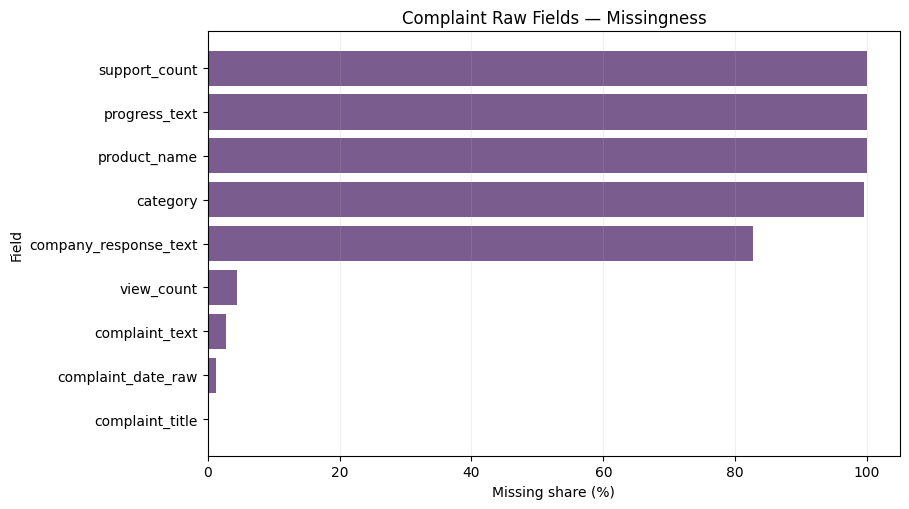

In [8]:
fig, ax = plt.subplots(figsize=(9.2, 5.2))
missing_plot = focus_missing.sort_values("missing_pct")
ax.barh(missing_plot["column_name"], missing_plot["missing_pct"], color="#7A5C8E")
ax.set(title="Complaint Raw Fields — Missingness", xlabel="Missing share (%)", ylabel="Field", xlim=(0, 105))
ax.grid(axis="x", alpha=0.2)
fig.tight_layout(); fig.savefig(FIGURES_DIR / "02_missingness.png", dpi=160, bbox_inches="tight"); plt.show(); plt.close(fig)


**Ne gösteriyor?** Seçili raw alanlardaki eksiklik oranını gösterir.

**Neden audit için önemli?** Hangi feature'ların kullanılabilir olduğunu ve structural missingness
ile gerçek veri kaybının ayrılması gerektiğini gösterir.

**Limitation:** Yüksek completeness semantik doğruluk anlamına gelmez; özellikle scraped alanların
HTML yapısına bağlılığı ayrıca değerlendirilmelidir.


## 07. Text quality audit

In [9]:
text_quality_summary = pd.DataFrame([
    ("Missing complaint text", int(complaints_prepared["complaint_text_missing_flag"].sum())),
    ("Missing complaint title", int(complaints_prepared["complaint_title_missing_flag"].sum())),
    (f"Very short complaint text (≤{very_short_threshold} words)", int(complaints_prepared["complaint_text_very_short_flag"].sum())),
    ("Possible boilerplate / repeated text", int(complaints_prepared["complaint_text_possible_boilerplate_flag"].sum())),
    ("HTML artifact in raw text", int(complaints_prepared["complaint_text_html_artifact_flag"].sum())),
    ("Encoding artifact in raw text", int(complaints_prepared["complaint_text_encoding_artifact_flag"].sum())),
    ("Potential email/phone PII pattern", int(complaints_prepared["potential_pii_flag"].sum())),
], columns=["Text quality flag", "Count"])
text_quality_summary["Share_pct"] = 100 * text_quality_summary["Count"] / len(complaints_prepared)
display(text_quality_summary)
display(Markdown(
    f"Very-short eşiği gerçek dağılımın alt %5 kuyruğu incelenerek, aşırı flag üretmemek için "
    f"**{very_short_threshold} kelime** ile konservatif biçimde sınırlandı. Kayıtlar drop edilmedi."
))


,Text quality flag,Count,Share_pct
0,Missing complaint text,7,2.822581
1,Missing complaint title,0,0.000000
2,Very short complaint text (≤40 words),6,2.419355
3,Possible boilerplate / repeated text,6,2.419355
4,HTML artifact in raw text,0,0.000000
5,Encoding artifact in raw text,0,0.000000
6,Potential email/phone PII pattern,53,21.370968


Very-short eşiği gerçek dağılımın alt %5 kuyruğu incelenerek, aşırı flag üretmemek için **40 kelime** ile konservatif biçimde sınırlandı. Kayıtlar drop edilmedi.

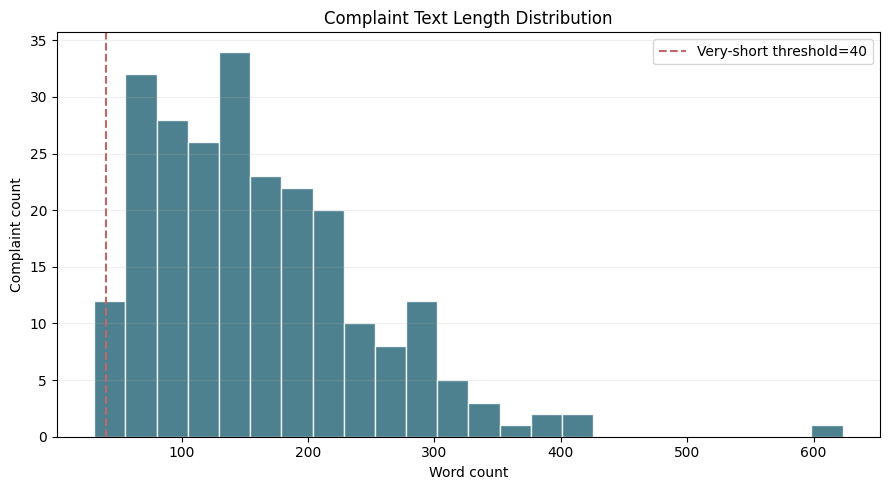

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
word_counts = complaints_prepared["complaint_word_count"].dropna().astype(int)
ax.hist(word_counts, bins=24, color="#2F6B7C", alpha=0.85, edgecolor="white")
ax.axvline(very_short_threshold, color="#C1666B", linestyle="--", label=f"Very-short threshold={very_short_threshold}")
ax.set(title="Complaint Text Length Distribution", xlabel="Word count", ylabel="Complaint count")
ax.legend(); ax.grid(axis="y", alpha=0.2)
fig.tight_layout(); fig.savefig(FIGURES_DIR / "03_text_length_distribution.png", dpi=160, bbox_inches="tight"); plt.show(); plt.close(fig)


**Ne gösteriyor?** Minimal temizlenmiş complaint metinlerinin kelime uzunluğu dağılımını ve
konservatif very-short eşiğini gösterir.

**Neden audit için önemli?** Boş/çok kısa kayıtların sonraki EDA ve NLP'de ayrı izlenmesini sağlar.

**Limitation:** Kısa metin otomatik olarak düşük kaliteli değildir; bu nedenle hiçbir kayıt yalnız
uzunluk nedeniyle silinmez.


## 08. Minimal text cleaning

In [11]:
text_cleaning_examples = complaints_prepared[[
    "complaint_id", "complaint_title", "complaint_title_clean", "complaint_text", "complaint_text_clean"
]].head(5).copy()
for column in ["complaint_text", "complaint_text_clean"]:
    text_cleaning_examples[column] = text_cleaning_examples[column].astype("string").str.slice(0, 180)
display(text_cleaning_examples)
display(Markdown(
    "Raw `complaint_title`, `complaint_text`, `company_response_text` ve `progress_text` kolonları "
    "aynen korunur. Yeni `*_clean` kolonları yalnız whitespace, linebreak, zero-width, HTML entity/tag, "
    "control-character ve Unicode standardizasyonu içerir."
))


,complaint_id,complaint_title,complaint_title_clean,complaint_text,complaint_text_clean
0,arin-resort-bodrum-memnuniyetsizligi,Memnuniyetsizliği,Memnuniyetsizliği,Balayı için geldiğimiz bu otelde ilk günden büyük olumsuzluklar yaşadık havanın 40 derece olduğu...,Balayı için geldiğimiz bu otelde ilk günden büyük olumsuzluklar yaşadık havanın 40 derece olduğu...
1,plaj-yaniltmasi-ve-guvenlik-endisesi-nedeniyle-tam-iptal-ve-80126-tl-iade-talebi,Plaj Yanıltması Ve Güvenlik Endişesi Nedeniyle Tam İptal Ve 80.126 TL İade Talebi,Plaj Yanıltması Ve Güvenlik Endişesi Nedeniyle Tam İptal Ve 80.126 TL İade Talebi,Tatilbudur üzerinden 5609***63 numaralı rezervasyonla Azure By Yelken Hotel’de 4 gecelik konakla...,Tatilbudur üzerinden 5609***63 numaralı rezervasyonla Azure By Yelken Hotel’de 4 gecelik konakla...
2,soz-verilen-2500-tl-kampanya-odulu-alinmadi-ve-yaniltici-bilgilendirme,Söz Verilen 2500 TL Kampanya Ödülü Alınmadı Ve Yanıltıcı Bilgilendirme,Söz Verilen 2500 TL Kampanya Ödülü Alınmadı Ve Yanıltıcı Bilgilendirme,"Tatilbudur internet sitesi üzerinden 5407***46 numaralı rezervasyonumu, özellikle sunulan 2.500 ...","Tatilbudur internet sitesi üzerinden 5407***46 numaralı rezervasyonumu, özellikle sunulan 2.500 ..."
3,azure-by-yelken-otelinde-temizlik-ve-hizmet-sorunlari-iade-talebi,Azure By Yelken Otelinde Temizlik Ve Hizmet Sorunları İade Talebi,Azure By Yelken Otelinde Temizlik Ve Hizmet Sorunları İade Talebi,Temmuz ayının 20’si ile 27’si arasında Azure By Yelken otelde konakladık ve ödediğimiz ücreti ke...,Temmuz ayının 20’si ile 27’si arasında Azure By Yelken otelde konakladık ve ödediğimiz ücreti ke...
4,ultra-her-sey-dahil-konseptinde-lobi-bar-ve-snack-bar-kapanmasi-ve-hamburger-ekmek-eksikligi-ned...,Ultra Her Şey Dahil Konseptinde Lobi Bar Ve Snack Bar Kapanması Ve Hamburger Ekmek Eksikliği Ned...,Ultra Her Şey Dahil Konseptinde Lobi Bar Ve Snack Bar Kapanması Ve Hamburger Ekmek Eksikliği Ned...,"03–07 Temmuz 2026 tarihleri arasında Azure by Yelken Bodrum’da, 5 yıldız ve Ultra her şey dahil ...","03–07 Temmuz 2026 tarihleri arasında Azure by Yelken Bodrum’da, 5 yıldız ve Ultra her şey dahil ..."


Raw `complaint_title`, `complaint_text`, `company_response_text` ve `progress_text` kolonları aynen korunur. Yeni `*_clean` kolonları yalnız whitespace, linebreak, zero-width, HTML entity/tag, control-character ve Unicode standardizasyonu içerir.

### Bölüm Sonucu

Minimal cleaning metnin dilsel içeriğini değiştirmez. Emoji, noktalama, olumsuzluk, yazım biçimi ve
kelime seçimi korunur; sonraki NLP kararları bu notebookta verilmez.


## 09. Date parsing

In [12]:
date_patterns = (
    complaints_prepared.groupby("complaint_date_pattern", dropna=False)
    .agg(
        row_count=("complaint_id", "size"),
        parse_success_count=("complaint_date", lambda values: int(values.notna().sum())),
        approximate_count=("complaint_date_is_approximate", lambda values: int(values.fillna(False).sum())),
        example=("complaint_date_raw", lambda values: next((str(value) for value in values if pd.notna(value)), "")),
    )
    .reset_index()
)
date_patterns["parse_success_pct"] = 100 * date_patterns["parse_success_count"] / date_patterns["row_count"]
date_patterns.to_csv(REPORTS_DIR / "sikayetvar_date_parse_patterns.csv", index=False)
display(date_patterns)

date_parse_success = int(complaints_prepared["complaint_date"].notna().sum())
date_parse_failed = int(complaints_prepared["complaint_date"].isna().sum())
date_approximate = int(complaints_prepared["complaint_date_is_approximate"].fillna(False).sum())
display(Markdown(
    f"Raw corpus date parse: **{date_parse_success}/{len(complaints_prepared)}** "
    f"(%{100*date_parse_success/len(complaints_prepared):.1f}); failed/missing={date_parse_failed}; "
    f"year inferred/relative approximate={date_approximate}; future-date flag="
    f"{int(complaints_prepared['complaint_date_future_flag'].sum())}."
))


,complaint_date_pattern,row_count,parse_success_count,approximate_count,example,parse_success_pct
0,DAY_MONTH_TIME_NO_YEAR,91,91,91,24 Ağustos 14:01,100.0
1,DAY_MONTH_YEAR_TIME,147,147,0,27 Haziran 2025 11:39,100.0
2,MISSING,3,0,0,,0.0
3,UNRECOGNIZED,7,0,0,Taha'nın Teşekkür Mesajı “ Misafir ilişkileri ile ilgilenen hanımefendiye teşekkür ediyorum çok ...,0.0


Raw corpus date parse: **238/248** (%96.0); failed/missing=10; year inferred/relative approximate=91; future-date flag=0.

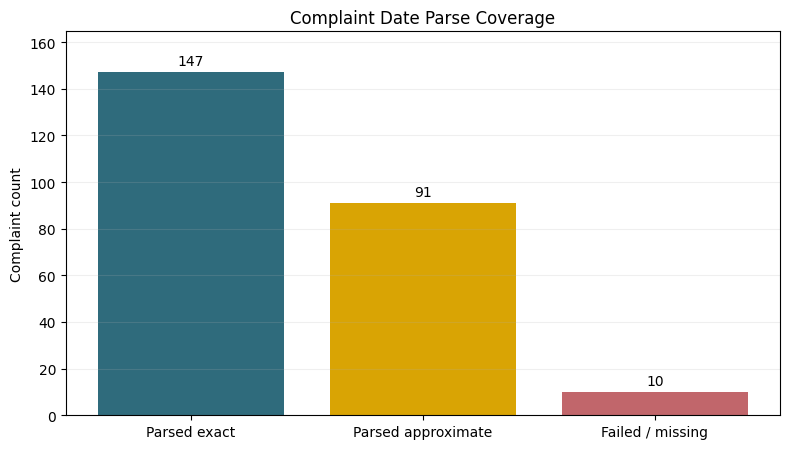

In [13]:
date_plot = pd.DataFrame({
    "Status": ["Parsed exact", "Parsed approximate", "Failed / missing"],
    "Count": [
        int((complaints_prepared["complaint_date"].notna() & ~complaints_prepared["complaint_date_is_approximate"].fillna(False)).sum()),
        date_approximate,
        date_parse_failed,
    ],
})
fig, ax = plt.subplots(figsize=(8, 4.6))
colors = ["#2F6B7C", "#D9A404", "#C1666B"]
ax.bar(date_plot["Status"], date_plot["Count"], color=colors)
for index, value in enumerate(date_plot["Count"]):
    ax.text(index, value + 3, str(value), ha="center")
ax.set(title="Complaint Date Parse Coverage", ylabel="Complaint count")
ax.set_ylim(0, date_plot["Count"].max() * 1.12)
ax.grid(axis="y", alpha=0.2)
fig.tight_layout(); fig.savefig(FIGURES_DIR / "04_date_parse_coverage.png", dpi=160, bbox_inches="tight"); plt.show(); plt.close(fig)


**Ne gösteriyor?** Tarihi kesin parse edilen, yılı collection timestamp'inden türetilen
approximate ve parse edilemeyen/missing kayıt sayılarını gösterir.

**Neden audit için önemli?** Temporal EDA'da kesin ve approximate tarihlerin ayrılmasını sağlar.

**Limitation:** Yılı görünmeyen tarihler deterministic biçimde collection yılına veya geleceğe
düşüyorsa önceki yıla atanır; bu kayıtlar `complaint_date_is_approximate=True` taşır.


## 10. Numeric field parsing

In [14]:
numeric_audit = pd.DataFrame([
    ("view_count", int(complaints_raw["view_count"].notna().sum()), int(complaints_prepared["view_count_numeric"].notna().sum()), int(complaints_prepared["view_count_parse_failed_flag"].sum()), "1.234 / 1,2 B / 1.2K supported"),
    ("support_count", int(complaints_raw["support_count"].notna().sum()), int(complaints_prepared["support_count_numeric"].notna().sum()), int((complaints_raw["support_count"].notna() & complaints_prepared["support_count_numeric"].isna()).sum()), "Missing remains NaN; never zero"),
    ("user_reply_count", int(complaints_raw["user_reply_count"].notna().sum()), int(complaints_prepared["user_reply_count_numeric"].notna().sum()), int((complaints_raw["user_reply_count"].notna() & complaints_prepared["user_reply_count_numeric"].isna()).sum()), "Nullable integer"),
], columns=["Raw field", "Non-null raw", "Parsed numeric", "Parse failed", "Policy"])
display(numeric_audit)

boolean_audit = pd.DataFrame([
    ("company_response_exists", int(complaints_prepared["company_response_exists_clean"].notna().sum()), sorted(complaints_prepared["company_response_exists_clean"].dropna().unique().tolist())),
    ("progress_exists", int(complaints_prepared["progress_exists_clean"].notna().sum()), sorted(complaints_prepared["progress_exists_clean"].dropna().unique().tolist())),
], columns=["Boolean field", "Parsed count", "Valid values"])
display(boolean_audit)


,Raw field,Non-null raw,Parsed numeric,Parse failed,Policy
0,view_count,237,237,0,"1.234 / 1,2 B / 1.2K supported"
1,support_count,0,0,0,Missing remains NaN; never zero
2,user_reply_count,248,248,0,Nullable integer


,Boolean field,Parsed count,Valid values
0,company_response_exists,248,"[False, True]"
1,progress_exists,248,[False]


### Bölüm Sonucu

Numeric parsing yeni değer uydurmaz. Görüntülenme formatları integer sayıya standardize edilir;
parse edilemeyen dolu değer flag'lenir. `support_count` tamamen missing ise tamamen missing kalır.


## 11. Reply dataset audit

In [15]:
complaint_reference_dates = (
    complaints_prepared.sort_values(
        "entity_match_status", key=lambda series: series.map({"COMPLAINT_MATCHED": 0, "COMPLAINT_REVIEW_REQUIRED": 1}).fillna(9)
    )
    .drop_duplicates("canonical_complaint_url")
    .set_index("canonical_complaint_url")["collected_at_parsed"]
)
replies_prepared = prepare_replies(replies_raw, complaint_reference_dates)

reply_schema = pd.DataFrame([
    {
        "column_name": column,
        "dtype": str(replies_raw[column].dtype),
        "non_null_count": int(replies_raw[column].notna().sum()),
        "missing_count": int(replies_raw[column].isna().sum()),
        "unique_count": int(replies_raw[column].nunique(dropna=True)),
    }
    for column in replies_raw.columns
])
display(reply_schema)

reply_duplicate_audit = replies_prepared.loc[
    replies_prepared["reply_id"].duplicated(keep=False),
    ["reply_id", "complaint_id", "canonical_complaint_url", "hotel_id", "reply_order", "reply_author_type", "reply_text"],
].copy()
reply_duplicate_audit.to_csv(REPORTS_DIR / "sikayetvar_reply_duplicate_audit.csv", index=False)

orphan_replies = replies_prepared.loc[
    ~replies_prepared["canonical_complaint_url"].isin(set(complaints_raw["canonical_complaint_url"].dropna()))
].copy()
orphan_replies.to_csv(REPORTS_DIR / "sikayetvar_orphan_replies_audit.csv", index=False)

reply_author_summary = (
    replies_prepared["reply_author_type_clean"].value_counts(dropna=False)
    .rename_axis("reply_author_type").reset_index(name="reply_count")
)
display(reply_author_summary)
display(Markdown(
    f"Stable `reply_id` duplicate={int(replies_prepared['reply_id'].duplicated().sum())}; "
    f"orphan reply={len(orphan_replies)}; reply date parsed="
    f"{int(replies_prepared['reply_date'].notna().sum())}/{len(replies_prepared)}."
))


,column_name,dtype,non_null_count,missing_count,unique_count
0,complaint_id,object,97,0,62
1,canonical_complaint_url,object,97,0,62
2,hotel_id,object,97,0,20
3,hotel_name,object,97,0,20
4,reply_order,object,97,0,6
5,reply_author_type,object,97,0,2
6,reply_date_raw,object,97,0,97
7,reply_text,object,97,0,96


,reply_author_type,reply_count
0,USER,56
1,COMPANY,41


Stable `reply_id` duplicate=0; orphan reply=0; reply date parsed=97/97.

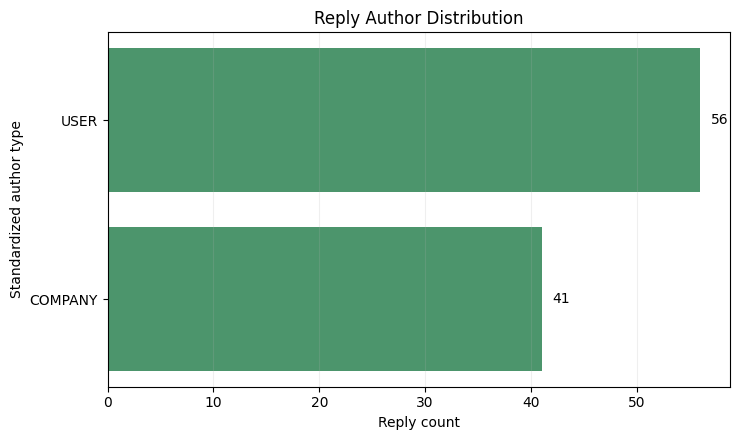

In [16]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
reply_plot = reply_author_summary.sort_values("reply_count")
ax.barh(reply_plot["reply_author_type"], reply_plot["reply_count"], color="#4C956C")
for index, value in enumerate(reply_plot["reply_count"]):
    ax.text(value + 1, index, str(value), va="center")
ax.set(title="Reply Author Distribution", xlabel="Reply count", ylabel="Standardized author type")
ax.grid(axis="x", alpha=0.2)
fig.tight_layout(); fig.savefig(FIGURES_DIR / "05_reply_author_distribution.png", dpi=160, bbox_inches="tight"); plt.show(); plt.close(fig)


**Ne gösteriyor?** Raw reply kayıtlarının standardize COMPANY/USER/UNKNOWN dağılımını gösterir.

**Neden audit için önemli?** Complaint-level company/user reply metriklerinin hangi kayıtlardan
türetildiğini görünür kılar.

**Limitation:** Author extraction HTML yapısına bağlıdır; UNKNOWN kategorisi ileride manuel olarak
incelenebilir ve reply varlığı çözüm kalitesi anlamına gelmez.


## 12. Referential integrity

In [17]:
status_priority = {"COMPLAINT_MATCHED": 0, "COMPLAINT_REVIEW_REQUIRED": 1, "COMPLAINT_EXCLUDED_OTHER_PROPERTY": 2}
complaints_unique_for_reply_audit = (
    complaints_prepared.assign(_status_priority=complaints_prepared["entity_match_status"].map(status_priority).fillna(9))
    .sort_values(["canonical_complaint_url", "_status_priority"])
    .drop_duplicates("canonical_complaint_url")
    .drop(columns="_status_priority")
)
reply_metrics = derive_reply_metrics(replies_prepared)
reply_consistency = complaints_unique_for_reply_audit.merge(
    reply_metrics, on="canonical_complaint_url", how="left", validate="one_to_one"
)
reply_count_columns = [
    "reply_count_total_derived", "reply_count_company_derived",
    "reply_count_user_derived", "reply_count_unknown_derived",
]
for column in reply_count_columns:
    reply_consistency[column] = reply_consistency[column].fillna(0).astype("Int64")
reply_consistency["company_reply_exists_derived"] = reply_consistency[
    "company_reply_exists_derived"
].fillna(False).astype("boolean")
reply_consistency["user_reply_count_mismatch_flag"] = (
    reply_consistency["user_reply_count_numeric"].fillna(0)
    .ne(reply_consistency["reply_count_user_derived"])
)
reply_consistency["company_response_mismatch_flag"] = (
    reply_consistency["company_response_exists_clean"].fillna(False)
    .ne(reply_consistency["company_reply_exists_derived"].fillna(False))
)
reply_count_consistency = reply_consistency[[
    "complaint_id", "canonical_complaint_url", "hotel_id", "hotel_name", "entity_match_status",
    "user_reply_count_numeric", "reply_count_total_derived", "reply_count_company_derived",
    "reply_count_user_derived", "reply_count_unknown_derived", "company_response_exists_clean",
    "company_reply_exists_derived", "user_reply_count_mismatch_flag", "company_response_mismatch_flag",
]].copy()
reply_count_consistency.to_csv(REPORTS_DIR / "sikayetvar_reply_count_consistency.csv", index=False)

display(pd.DataFrame([
    ("Raw replies", len(replies_raw)),
    ("Replies linked to a raw complaint", len(replies_raw) - len(orphan_replies)),
    ("Orphan replies", len(orphan_replies)),
    ("User reply count mismatches", int(reply_consistency["user_reply_count_mismatch_flag"].sum())),
    ("Company response/reply mismatches", int(reply_consistency["company_response_mismatch_flag"].sum())),
], columns=["Referential integrity metric", "Count"]))
display(reply_count_consistency.loc[
    reply_count_consistency["user_reply_count_mismatch_flag"]
    | reply_count_consistency["company_response_mismatch_flag"]
])


/var/folders/35/w7v4jvv930z1wthrlzsp49th0000gn/T/ipykernel_94218/985996907.py:18: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  reply_consistency["company_reply_exists_derived"] = reply_consistency[


,Referential integrity metric,Count
0,Raw replies,97
1,Replies linked to a raw complaint,97
2,Orphan replies,0
3,User reply count mismatches,0
4,Company response/reply mismatches,4


,complaint_id,canonical_complaint_url,hotel_id,hotel_name,entity_match_status,user_reply_count_numeric,reply_count_total_derived,reply_count_company_derived,reply_count_user_derived,reply_count_unknown_derived,company_response_exists_clean,company_reply_exists_derived,user_reply_count_mismatch_flag,company_response_mismatch_flag
153,oscar-seaside-hotel-spa-bodrum-hicbir-sey-dahil-degil-konsept,https://www.sikayetvar.com/oscar-seaside-hotel-spa-bodrum/oscar-seaside-hotel-spa-bodrum-hicbir-...,BOD109,Oscar Seaside Hotel & Spa,COMPLAINT_REVIEW_REQUIRED,0,0,0,0,0,True,False,False,True
154,oscar-seaside-hotel-spa-bodrum-iptal-sonrasi-29000-tl-iadesi-yapilmiyor,https://www.sikayetvar.com/oscar-seaside-hotel-spa-bodrum/oscar-seaside-hotel-spa-bodrum-iptal-s...,BOD109,Oscar Seaside Hotel & Spa,COMPLAINT_REVIEW_REQUIRED,0,0,0,0,0,True,False,False,True
155,oscar-seaside-hotel-spa-bodrum-memnuniyetsizlik,https://www.sikayetvar.com/oscar-seaside-hotel-spa-bodrum/oscar-seaside-hotel-spa-bodrum-memnuni...,BOD109,Oscar Seaside Hotel & Spa,COMPLAINT_REVIEW_REQUIRED,0,0,0,0,0,True,False,False,True
157,otel-rezervasyon-iptalinde-ucret-iadesi-yapilmiyor-magdur-edildim,https://www.sikayetvar.com/oscar-seaside-hotel-spa-bodrum/otel-rezervasyon-iptalinde-ucret-iades...,BOD109,Oscar Seaside Hotel & Spa,COMPLAINT_REVIEW_REQUIRED,0,0,0,0,0,True,False,False,True


### Bölüm Sonucu

Reply linkage canonical URL üzerinden doğrulanır. Raw complaintteki user-reply ve company-response
flag'leri replies-derived sayılarla sessizce overwrite edilmez; iki kaynak yan yana korunur ve
mismatch flag'i üretilir.


## 13. Company response validation

In [18]:
response_text_present = complaints_prepared["company_response_text_clean"].notna()
progress_text_present = complaints_prepared["progress_text_clean"].notna()
company_response_consistency = pd.DataFrame([
    ("response_true_text_missing", int((complaints_prepared["company_response_exists_clean"].eq(True) & ~response_text_present).sum())),
    ("response_false_text_present", int((complaints_prepared["company_response_exists_clean"].eq(False) & response_text_present).sum())),
    ("progress_true_text_missing", int((complaints_prepared["progress_exists_clean"].eq(True) & ~progress_text_present).sum())),
    ("progress_false_text_present", int((complaints_prepared["progress_exists_clean"].eq(False) & progress_text_present).sum())),
], columns=["check", "issue_count"])
company_response_consistency["share_pct"] = 100 * company_response_consistency["issue_count"] / len(complaints_prepared)
company_response_consistency["status"] = np.where(company_response_consistency["issue_count"].eq(0), "PASS", "REVIEW")
company_response_consistency.to_csv(REPORTS_DIR / "sikayetvar_company_response_consistency.csv", index=False)
display(company_response_consistency)
display(Markdown(
    "Company response text/flag tutarlılığı ile replies-derived COMPANY kaydı ayrı kontrollerdir. "
    "Response varlığı çözüm, memnuniyet veya başarılı resolution anlamına gelmez."
))


,check,issue_count,share_pct,status
0,response_true_text_missing,0,0.0,PASS
1,response_false_text_present,0,0.0,PASS
2,progress_true_text_missing,0,0.0,PASS
3,progress_false_text_present,0,0.0,PASS


Company response text/flag tutarlılığı ile replies-derived COMPANY kaydı ayrı kontrollerdir. Response varlığı çözüm, memnuniyet veya başarılı resolution anlamına gelmez.

## 14. Hotel master enrichment

In [19]:
master_columns = [
    "hotel_id", "hotel_name", "area", "google_rating", "google_review_count",
    "official_star_rating_verified", "official_room_count", "official_bed_count",
    "search_price_usd_snapshot",
]
available_master_columns = [column for column in master_columns if column in hotel_master.columns]
hotel_metadata = hotel_master[available_master_columns].copy()
assert hotel_metadata["hotel_id"].is_unique, "Hotel master join key unique değil."
hotel_metadata = hotel_metadata.rename(columns={"hotel_name": "hotel_name_master", "area": "area_master"})

before_join_rows = len(complaints_prepared)
complaints_enriched = complaints_prepared.merge(
    hotel_metadata, on="hotel_id", how="left", validate="many_to_one"
)
assert len(complaints_enriched) == before_join_rows, "Hotel metadata join complaint satırlarını çoğalttı."

complaints_enriched["hotel_name_mismatch_flag"] = (
    complaints_enriched["hotel_name"].map(normalize_for_duplicate)
    .ne(complaints_enriched["hotel_name_master"].map(normalize_for_duplicate))
)
complaints_enriched["area_mismatch_flag"] = (
    complaints_enriched["area"].fillna("").str.strip().str.casefold()
    .ne(complaints_enriched["area_master"].fillna("").str.strip().str.casefold())
)
complaints_enriched["hotel_metadata_mismatch_flag"] = (
    complaints_enriched["hotel_name_mismatch_flag"] | complaints_enriched["area_mismatch_flag"]
)

hotel_metadata_mismatches = complaints_enriched.loc[
    complaints_enriched["hotel_metadata_mismatch_flag"],
    ["complaint_id", "canonical_complaint_url", "hotel_id", "hotel_name", "hotel_name_master", "area", "area_master", "hotel_name_mismatch_flag", "area_mismatch_flag"],
].copy()
hotel_metadata_mismatches.to_csv(REPORTS_DIR / "sikayetvar_hotel_metadata_mismatches.csv", index=False)
display(pd.DataFrame([
    ("Complaint rows before join", before_join_rows),
    ("Complaint rows after join", len(complaints_enriched)),
    ("Missing hotel master join", int(complaints_enriched["hotel_name_master"].isna().sum())),
    ("Hotel name/area mismatches", len(hotel_metadata_mismatches)),
], columns=["Hotel enrichment check", "Count"]))


,Hotel enrichment check,Count
0,Complaint rows before join,248
1,Complaint rows after join,248
2,Missing hotel master join,0
3,Hotel name/area mismatches,0


### Bölüm Sonucu

Enrichment yalnız `hotel_id` üzerinden many-to-one yapılır; raw `hotel_name` ve `area` overwrite
edilmez. Master karşılıkları ayrı kolonlarda tutulur ve satır çoğalması assertion ile engellenir.


## 15. Clean corpus creation

In [20]:
matched_mask = complaints_enriched["entity_match_status"].eq("COMPLAINT_MATCHED")
review_mask = complaints_enriched["entity_match_status"].eq("COMPLAINT_REVIEW_REQUIRED")

matched_pre_dedupe = complaints_enriched.loc[matched_mask].copy()
clean_complaints = matched_pre_dedupe.drop_duplicates("canonical_complaint_url", keep="first").copy()
review_required_complaints = complaints_enriched.loc[review_mask].copy()
review_required_complaints["exact_duplicate_cross_assignment_flag"] = review_required_complaints[
    "canonical_complaint_url"
].isin(duplicate_canonical_urls)

reply_merge_columns = [
    "canonical_complaint_url", "reply_count_total_derived", "reply_count_company_derived",
    "reply_count_user_derived", "reply_count_unknown_derived", "first_reply_date", "last_reply_date",
    "company_reply_exists_derived", "user_reply_count_mismatch_flag", "company_response_mismatch_flag",
]
clean_complaints = clean_complaints.merge(
    reply_consistency[reply_merge_columns], on="canonical_complaint_url", how="left", validate="one_to_one"
)
for column in reply_count_columns:
    clean_complaints[column] = clean_complaints[column].fillna(0).astype("Int64")
clean_complaints["company_reply_exists_derived"] = clean_complaints[
    "company_reply_exists_derived"
].fillna(False).astype("boolean")
clean_complaints["user_reply_count_mismatch_flag"] = clean_complaints[
    "user_reply_count_mismatch_flag"
].fillna(False)
clean_complaints["company_response_mismatch_flag"] = clean_complaints[
    "company_response_mismatch_flag"
].fillna(False)

clean_replies = replies_prepared.loc[
    replies_prepared["canonical_complaint_url"].isin(set(clean_complaints["canonical_complaint_url"]))
].drop_duplicates("reply_id", keep="first").copy()

clean_complaints.to_csv(PROCESSED_DIR / "sikayetvar_all_hotels_complaints_clean.csv", index=False)
review_required_complaints.to_csv(PROCESSED_DIR / "sikayetvar_complaints_review_required.csv", index=False)
clean_replies.to_csv(PROCESSED_DIR / "sikayetvar_all_hotels_replies_clean.csv", index=False)

drop_records = []
matched_urls = set(clean_complaints["canonical_complaint_url"])
for _, row in complaints_enriched.loc[~matched_mask].iterrows():
    cross_assignment = row["canonical_complaint_url"] in matched_urls
    drop_records.append({
        "complaint_id": row["complaint_id"],
        "canonical_complaint_url": row["canonical_complaint_url"],
        "reason": "exact_duplicate_cross_assignment" if cross_assignment else "non_matched_entity",
        "action": "EXCLUDE_FROM_MAIN_CLEAN_CORPUS_KEEP_FOR_REVIEW" if row["entity_match_status"] == "COMPLAINT_REVIEW_REQUIRED" else "EXCLUDE_FROM_MAIN_CLEAN_CORPUS",
        "source_status": row["entity_match_status"],
    })
for _, row in matched_pre_dedupe.loc[matched_pre_dedupe.duplicated("canonical_complaint_url", keep="first")].iterrows():
    drop_records.append({
        "complaint_id": row["complaint_id"],
        "canonical_complaint_url": row["canonical_complaint_url"],
        "reason": "exact_duplicate_canonical_url",
        "action": "DROP_DUPLICATE_FROM_MAIN_CLEAN_CORPUS",
        "source_status": row["entity_match_status"],
    })
cleaning_drop_log = pd.DataFrame(
    drop_records,
    columns=["complaint_id", "canonical_complaint_url", "reason", "action", "source_status"],
)
cleaning_drop_log.to_csv(REPORTS_DIR / "sikayetvar_cleaning_drop_log.csv", index=False)

display(pd.DataFrame([
    ("Raw complaints", len(complaints_raw)),
    ("Raw complaint-level matched", int(matched_mask.sum())),
    ("Raw review-required", int(review_mask.sum())),
    ("Canonical duplicate excess in raw", canonical_duplicate_excess),
    ("Clean matched complaints", len(clean_complaints)),
    ("Review-required file rows", len(review_required_complaints)),
    ("Clean replies", len(clean_replies)),
], columns=["Corpus construction metric", "Count"]))


,Corpus construction metric,Count
0,Raw complaints,248
1,Raw complaint-level matched,236
2,Raw review-required,12
3,Canonical duplicate excess in raw,3
4,Clean matched complaints,236
5,Review-required file rows,12
6,Clean replies,97


In [21]:
preview_columns = [
    "complaint_id", "hotel_id", "hotel_name", "area", "complaint_date", "complaint_title_clean",
    "complaint_text_clean", "complaint_word_count", "view_count_numeric",
    "company_response_exists_clean", "reply_count_total_derived",
]
clean_preview = clean_complaints[preview_columns].head(8).copy()
clean_preview["complaint_text_clean"] = clean_preview["complaint_text_clean"].astype("string").str.slice(0, 180)
display(clean_preview)
display(Markdown(
    "Notebook preview okunabilirlik için truncate edilmiştir; processed CSV'de raw ve clean metinler "
    "tam uzunlukta korunur."
))


,complaint_id,hotel_id,hotel_name,area,complaint_date,complaint_title_clean,complaint_text_clean,complaint_word_count,view_count_numeric,company_response_exists_clean,reply_count_total_derived
0,arin-resort-bodrum-memnuniyetsizligi,BOD158,Arin Resort Bodrum,Turgutreis,2025-06-27 11:39:00,Memnuniyetsizliği,Balayı için geldiğimiz bu otelde ilk günden büyük olumsuzluklar yaşadık havanın 40 derece olduğu...,146,878,False,0
1,plaj-yaniltmasi-ve-guvenlik-endisesi-nedeniyle-tam-iptal-ve-80126-tl-iade-talebi,BOD112,Azure By Yelken Hotel,Kadıkalesi,2026-08-24 14:01:00,Plaj Yanıltması Ve Güvenlik Endişesi Nedeniyle Tam İptal Ve 80.126 TL İade Talebi,Tatilbudur üzerinden 5609***63 numaralı rezervasyonla Azure By Yelken Hotel’de 4 gecelik konakla...,226,<NA>,False,0
2,soz-verilen-2500-tl-kampanya-odulu-alinmadi-ve-yaniltici-bilgilendirme,BOD112,Azure By Yelken Hotel,Kadıkalesi,2026-08-12 20:04:00,Söz Verilen 2500 TL Kampanya Ödülü Alınmadı Ve Yanıltıcı Bilgilendirme,"Tatilbudur internet sitesi üzerinden 5407***46 numaralı rezervasyonumu, özellikle sunulan 2.500 ...",154,114,False,0
3,azure-by-yelken-otelinde-temizlik-ve-hizmet-sorunlari-iade-talebi,BOD112,Azure By Yelken Hotel,Kadıkalesi,2026-07-29 02:59:00,Azure By Yelken Otelinde Temizlik Ve Hizmet Sorunları İade Talebi,Temmuz ayının 20’si ile 27’si arasında Azure By Yelken otelde konakladık ve ödediğimiz ücreti ke...,194,375,False,0
4,ultra-her-sey-dahil-konseptinde-lobi-bar-ve-snack-bar-kapanmasi-ve-hamburger-ekmek-eksikligi-ned...,BOD112,Azure By Yelken Hotel,Kadıkalesi,2026-07-04 01:31:00,Ultra Her Şey Dahil Konseptinde Lobi Bar Ve Snack Bar Kapanması Ve Hamburger Ekmek Eksikliği Ned...,"03–07 Temmuz 2026 tarihleri arasında Azure by Yelken Bodrum’da, 5 yıldız ve Ultra her şey dahil ...",224,660,False,0
5,yetersiz-yemek-ve-icecek-sikici-aksam-etkinlikleriyle-hayal-kirikligi,BOD112,Azure By Yelken Hotel,Kadıkalesi,2026-06-03 23:52:00,"Yetersiz Yemek Ve İçecek, Sıkıcı Akşam Etkinlikleriyle Hayal Kırıklığı",Bodrum Turgutreis’te bulunan Azure By Yelken Otel’de şu an Ultra her şey dahil konaklıyoruz. Paz...,206,1371,True,3
6,personel-yetersizligi-ve-hijyen-sorunlari-tatil-deneyimini-mahvediyor,BOD112,Azure By Yelken Hotel,Kadıkalesi,2026-05-31 12:34:00,Personel Yetersizliği Ve Hijyen Sorunları Tatil Deneyimini Mahvediyor,Azure by Yelken Hotel Bodrum’da 25–28 Mayıs tarihleri arasında 3335 numaralı odada toplam 44 bin...,234,1209,False,0
7,hijyen-ve-hizmet-cokusu-azur-by-yelken-bodrum-otelinde,BOD112,Azure By Yelken Hotel,Kadıkalesi,2026-05-27 00:24:00,Hijyen Ve Hizmet Çöküşü: Azur By Yelken Bodrum Otelinde,25–30 Mayıs tarihleri arasında Azur by Yelken Bodrum otelinde standart odada 5 gece konakladık v...,217,836,False,0


Notebook preview okunabilirlik için truncate edilmiştir; processed CSV'de raw ve clean metinler tam uzunlukta korunur.

### Bölüm Sonucu

Ana processed corpus yalnız complaint-level kesin eşleşmeleri içerir. Review-required kayıtlar ayrı
dosyada ve manual review kanıtlarıyla korunur. Missing tarih, view veya kısa metin otomatik drop
nedeni değildir.


## 16. Hotel coverage

In [22]:
hotel_base = hotel_master[["hotel_id", "hotel_name", "area"]].copy()
mapping_for_coverage = hotel_mapping[[
    "hotel_id", "match_status", "page_accessible", "visible_complaint_count"
]].rename(columns={"match_status": "mapping_status"})
hotel_coverage = hotel_base.merge(mapping_for_coverage, on="hotel_id", how="left", validate="one_to_one")

matched_hotel_agg = clean_complaints.groupby("hotel_id").agg(
    matched_complaint_count=("complaint_id", "size"),
    first_complaint_date=("complaint_date", "min"),
    last_complaint_date=("complaint_date", "max"),
    avg_complaint_word_count=("complaint_word_count", "mean"),
    median_complaint_word_count=("complaint_word_count", "median"),
    company_response_count=("company_response_exists_clean", lambda values: int(values.fillna(False).sum())),
    complaints_with_replies=("reply_count_total_derived", lambda values: int(values.gt(0).sum())),
    total_reply_count=("reply_count_total_derived", "sum"),
    view_count_non_null=("view_count_numeric", "count"),
    median_view_count=("view_count_numeric", "median"),
).reset_index()
review_hotel_agg = (
    review_required_complaints.groupby("hotel_id").size()
    .rename("review_required_complaint_count").reset_index()
)
hotel_coverage = hotel_coverage.merge(matched_hotel_agg, on="hotel_id", how="left", validate="one_to_one")
hotel_coverage = hotel_coverage.merge(review_hotel_agg, on="hotel_id", how="left", validate="one_to_one")
count_columns = [
    "matched_complaint_count", "review_required_complaint_count", "company_response_count",
    "complaints_with_replies", "total_reply_count", "view_count_non_null",
]
for column in count_columns:
    hotel_coverage[column] = hotel_coverage[column].fillna(0).astype(int)
hotel_coverage["company_response_rate_in_corpus"] = np.where(
    hotel_coverage["matched_complaint_count"].gt(0),
    100 * hotel_coverage["company_response_count"] / hotel_coverage["matched_complaint_count"],
    np.nan,
)
hotel_coverage["view_count_coverage_pct"] = np.where(
    hotel_coverage["matched_complaint_count"].gt(0),
    100 * hotel_coverage["view_count_non_null"] / hotel_coverage["matched_complaint_count"],
    np.nan,
)
hotel_coverage.to_csv(REPORTS_DIR / "sikayetvar_clean_coverage_by_hotel.csv", index=False)
display(hotel_coverage.sort_values("matched_complaint_count", ascending=False).head(15))


,hotel_id,hotel_name,area,mapping_status,page_accessible,visible_complaint_count,matched_complaint_count,first_complaint_date,last_complaint_date,avg_complaint_word_count,median_complaint_word_count,company_response_count,complaints_with_replies,total_reply_count,view_count_non_null,median_view_count,review_required_complaint_count,company_response_rate_in_corpus,view_count_coverage_pct
6,BOD007,Kefaluka Resort,Akyarlar,FOUND_EXACT,True,22,29,2023-08-28 21:04:00,2026-08-22 11:58:00,170.111111,165.0,22,23,46,28,921.5,0,75.862069,96.551724
111,BOD112,Azure By Yelken Hotel,Kadıkalesi,FOUND_EXACT,True,22,26,2024-06-06 19:39:00,2026-08-24 14:01:00,181.423077,184.5,1,1,3,25,2076.0,0,3.846154,96.153846
114,BOD115,Yasmin Bodrum Resort,Kadıkalesi,FOUND_EXACT,True,18,23,2024-06-05 18:09:00,2026-08-23 11:09:00,127.190476,107.0,0,0,0,23,1437.0,0,0.000000,100.000000
105,BOD106,La Blanche Island Bodrum,Güvercinlik,FOUND_EXACT,True,16,19,2024-06-17 08:33:00,2026-08-05 09:16:00,161.833333,150.0,5,6,9,19,922.0,0,26.315789,100.000000
129,BOD130,Petunya Beach Resort,Ortakent-Yahşi,FOUND_EXACT,True,13,13,2023-09-10 23:45:00,2026-08-12 09:35:00,153.461538,147.0,0,2,2,11,529.0,0,0.000000,84.615385
3,BOD004,Bendis Beach Hotel,Akyarlar,FOUND_EXACT,True,12,12,2024-07-23 10:26:00,2026-08-11 10:24:00,190.416667,132.0,5,6,9,11,983.0,0,41.666667,91.666667
159,BOD160,La Blanche Resort Bodrum,Turgutreis,FOUND_HIGH_CONFIDENCE,True,12,12,2023-10-17 18:40:00,2026-08-22 15:55:00,135.916667,120.5,0,1,1,12,885.0,0,0.000000,100.000000
102,BOD103,Green Bay Resort & Spa Bodrum,Güvercinlik,FOUND_EXACT,True,11,11,2024-09-09 00:57:00,2026-08-07 18:50:00,213.2,198.5,0,2,2,11,547.0,0,0.000000,100.000000
152,BOD153,The Oba Hotel,Torba,FOUND_EXACT,True,10,10,2024-06-15 19:54:00,2025-09-14 18:39:00,100.4,72.5,0,1,1,10,3080.5,0,0.000000,100.000000
67,BOD068,Selectum Colours Bodrum,Gümbet,REVIEW_REQUIRED,True,14,8,2024-06-09 12:08:00,2026-08-21 14:54:00,159.375,140.0,0,0,0,8,263.0,6,0.000000,100.000000


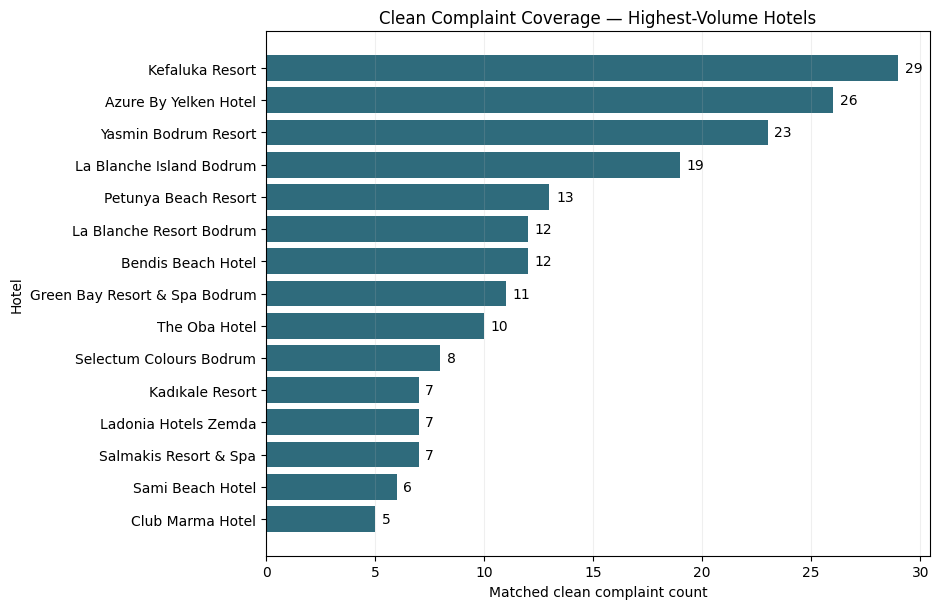

In [23]:
hotel_plot = hotel_coverage.nlargest(15, "matched_complaint_count").sort_values("matched_complaint_count")
fig, ax = plt.subplots(figsize=(9.5, 6.2))
ax.barh(hotel_plot["hotel_name"], hotel_plot["matched_complaint_count"], color="#2F6B7C")
for index, value in enumerate(hotel_plot["matched_complaint_count"]):
    ax.text(value + 0.3, index, str(value), va="center")
ax.set(title="Clean Complaint Coverage — Highest-Volume Hotels", xlabel="Matched clean complaint count", ylabel="Hotel")
ax.grid(axis="x", alpha=0.2)
fig.tight_layout(); fig.savefig(FIGURES_DIR / "06_clean_coverage_by_hotel.png", dpi=160, bbox_inches="tight"); plt.show(); plt.close(fig)


**Ne gösteriyor?** Clean corpusta en fazla complaint kaydı bulunan otelleri bir coverage
göstergesi olarak gösterir.

**Neden audit için önemli?** Sonraki analizlerde hotel örneklem büyüklüklerinin ne kadar dengesiz
olduğunu görünür kılar.

**Limitation:** Complaint hacmi kalite, complaint rate veya müşteri sayısı değildir; platform
mapping ve self-selection etkisini taşır.


## 17. Area coverage

In [24]:
area_coverage = hotel_base.groupby("area").agg(project_hotel_count=("hotel_id", "size")).reset_index()
mapping_status_counts = (
    hotel_mapping.pivot_table(index="area", columns="match_status", values="hotel_id", aggfunc="size", fill_value=0)
    .add_prefix("mapping_status_").reset_index()
)
mapped_statuses = {"FOUND_EXACT", "FOUND_HIGH_CONFIDENCE"}
mapped_hotels = (
    hotel_mapping.loc[hotel_mapping["match_status"].isin(mapped_statuses)]
    .groupby("area")["hotel_id"].nunique().rename("mapped_hotel_count").reset_index()
)
area_clean = clean_complaints.groupby("area").agg(
    hotels_with_matched_complaints=("hotel_id", "nunique"),
    matched_complaint_count=("complaint_id", "size"),
    company_response_count=("company_response_exists_clean", lambda values: int(values.fillna(False).sum())),
).reset_index()
area_coverage = area_coverage.merge(mapped_hotels, on="area", how="left").merge(area_clean, on="area", how="left").merge(mapping_status_counts, on="area", how="left")
for column in area_coverage.columns:
    if column != "area":
        area_coverage[column] = area_coverage[column].fillna(0)
area_coverage["mapped_hotel_count"] = area_coverage["mapped_hotel_count"].astype(int)
area_coverage["hotels_with_matched_complaints"] = area_coverage["hotels_with_matched_complaints"].astype(int)
area_coverage["matched_complaint_count"] = area_coverage["matched_complaint_count"].astype(int)
area_coverage["company_response_count"] = area_coverage["company_response_count"].astype(int)
area_coverage["complaint_share_pct"] = 100 * area_coverage["matched_complaint_count"] / len(clean_complaints)
area_coverage.to_csv(REPORTS_DIR / "sikayetvar_clean_coverage_by_area.csv", index=False)
display(area_coverage.sort_values("matched_complaint_count", ascending=False))


,area,project_hotel_count,mapped_hotel_count,hotels_with_matched_complaints,matched_complaint_count,company_response_count,mapping_status_AMBIGUOUS,mapping_status_FOUND_EXACT,mapping_status_FOUND_HIGH_CONFIDENCE,mapping_status_NOT_FOUND,mapping_status_PAGE_FOUND_NO_COMPLAINT,mapping_status_REVIEW_REQUIRED,complaint_share_pct
8,Kadıkalesi,4,3,3,56,3,0,3,0,1,0,0,23.728814
0,Akyarlar,16,5,6,55,31,0,5,0,7,1,3,23.305085
7,Güvercinlik,10,5,4,39,5,0,5,0,2,1,2,16.525424
4,Gümbet,15,6,7,24,0,0,6,0,4,0,5,10.169492
9,Ortakent-Yahşi,21,3,3,16,0,0,3,0,11,2,5,6.779661
2,Bodrum Merkez,13,3,3,13,0,0,3,0,4,1,5,5.508475
11,Turgutreis,7,2,2,13,0,0,1,1,3,0,2,5.508475
10,Torba,21,1,1,10,0,0,1,0,13,2,5,4.237288
5,Gümüşlük,15,1,1,7,0,0,1,0,10,0,4,2.966102
3,Göltürkbükü,10,1,1,2,0,0,1,0,7,1,1,0.847458


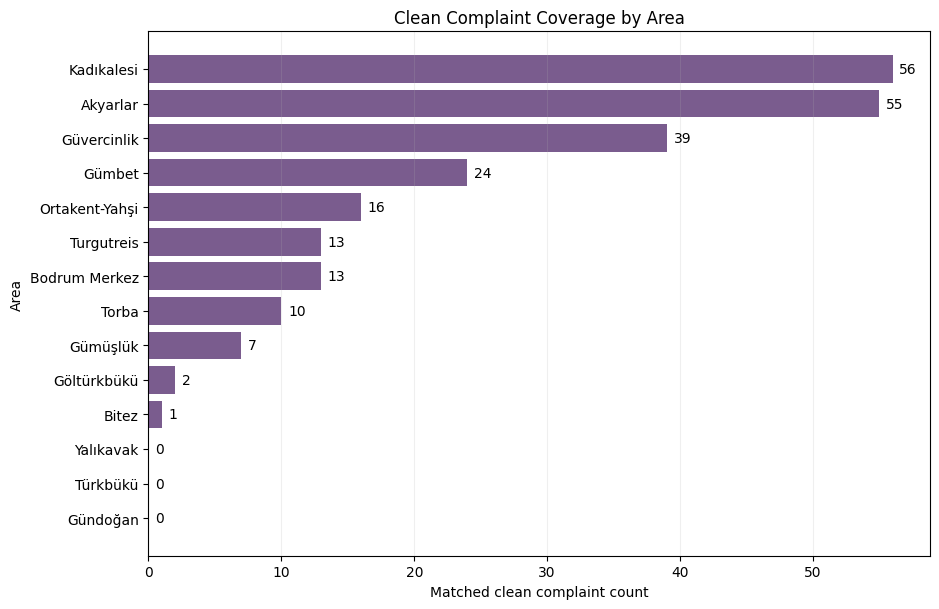

In [25]:
area_plot = area_coverage.sort_values("matched_complaint_count")
fig, ax = plt.subplots(figsize=(9.5, 6.2))
ax.barh(area_plot["area"], area_plot["matched_complaint_count"], color="#7A5C8E")
for index, value in enumerate(area_plot["matched_complaint_count"]):
    ax.text(value + 0.5, index, str(value), va="center")
ax.set(title="Clean Complaint Coverage by Area", xlabel="Matched clean complaint count", ylabel="Area")
ax.grid(axis="x", alpha=0.2)
fig.tight_layout(); fig.savefig(FIGURES_DIR / "07_clean_coverage_by_area.png", dpi=160, bbox_inches="tight"); plt.show(); plt.close(fig)


**Ne gösteriyor?** Clean complaint kayıtlarının destinasyonlara göre coverage dağılımını gösterir.

**Neden audit için önemli?** Area düzeyinde heterojen örneklem büyüklüğünü ve sıfır gözlemli alanları
sonraki analiz öncesinde görünür kılar.

**Limitation:** `NOT_FOUND`, `PAGE_FOUND_NO_COMPLAINT` ve sıfır matched complaint farklı durumlardır;
grafikteki sıfır gerçek complaint yokluğu veya yüksek kalite anlamına gelmez.


### Bölüm Sonucu

Hotel ve area coverage belirgin biçimde heterojendir. Mapping status ayrımları area raporunda ayrı
kolonlar olarak korunur; complaint hacmi hiçbir yerde normatif otel/destinasyon sıralamasına çevrilmez.


## 18. Data quality summary

In [26]:
raw_company_response_count = int(complaints_prepared["company_response_exists_clean"].fillna(False).sum())
clean_company_response_count = int(clean_complaints["company_response_exists_clean"].fillna(False).sum())
company_response_text_mismatch_count = int(
    company_response_consistency.loc[
        company_response_consistency["check"].isin(["response_true_text_missing", "response_false_text_present"]),
        "issue_count",
    ].sum()
)
reply_user_mismatch_count = int(reply_consistency["user_reply_count_mismatch_flag"].sum())
reply_company_mismatch_count = int(reply_consistency["company_response_mismatch_flag"].sum())
reply_any_mismatch_count = int(
    (reply_consistency["user_reply_count_mismatch_flag"] | reply_consistency["company_response_mismatch_flag"]).sum()
)
clean_date_parsed_count = int(clean_complaints["complaint_date"].notna().sum())
clean_date_failed_count = int(clean_complaints["complaint_date"].isna().sum())

quality_summary = pd.DataFrame([
    ("Raw complaint", len(complaints_raw), 100.0, "All extracted detail rows"),
    ("Complaint-level matched", int(matched_mask.sum()), 100 * matched_mask.mean(), "Eligible before canonical dedupe"),
    ("Review-required", int(review_mask.sum()), 100 * review_mask.mean(), "Excluded from main corpus; kept separately"),
    ("Canonical duplicate excess", canonical_duplicate_excess, 100 * canonical_duplicate_excess / len(complaints_raw), "Cross-assignment evidence retained in audit"),
    ("Clean processed complaint", len(clean_complaints), 100 * len(clean_complaints) / len(complaints_raw), "Matched + canonical unique"),
    ("Raw reply", len(replies_raw), 100.0, "All extracted replies"),
    ("Clean linked reply", len(clean_replies), 100 * len(clean_replies) / max(len(replies_raw), 1), "Linked to clean complaint corpus"),
    ("Orphan reply", len(orphan_replies), 100 * len(orphan_replies) / max(len(replies_raw), 1), "Must be zero for release"),
    ("Clean date parsed", clean_date_parsed_count, 100 * clean_date_parsed_count / len(clean_complaints), "Exact + flagged approximate"),
    ("Missing complaint text", int(clean_complaints["missing_text_flag"].sum()), 100 * clean_complaints["missing_text_flag"].mean(), "Retained with quality flag"),
    ("Very-short complaint text", int(clean_complaints["very_short_text_flag"].sum()), 100 * clean_complaints["very_short_text_flag"].mean(), "Retained with quality flag"),
    ("Raw company response", raw_company_response_count, 100 * raw_company_response_count / len(complaints_raw), "Flag/text consistency audited"),
    ("Reply-derived mismatch", reply_any_mismatch_count, 100 * reply_any_mismatch_count / len(reply_consistency), "Not silently overwritten"),
], columns=["Metric", "Count", "Share", "Interpretation"])
display(quality_summary)


,Metric,Count,Share,Interpretation
0,Raw complaint,248,100.000000,All extracted detail rows
1,Complaint-level matched,236,95.161290,Eligible before canonical dedupe
2,Review-required,12,4.838710,Excluded from main corpus; kept separately
3,Canonical duplicate excess,3,1.209677,Cross-assignment evidence retained in audit
4,Clean processed complaint,236,95.161290,Matched + canonical unique
5,Raw reply,97,100.000000,All extracted replies
6,Clean linked reply,97,100.000000,Linked to clean complaint corpus
7,Orphan reply,0,0.000000,Must be zero for release
8,Clean date parsed,226,95.762712,Exact + flagged approximate
9,Missing complaint text,7,2.966102,Retained with quality flag


In [27]:
cleaning_summary = pd.DataFrame([
    ("raw_complaint_count", len(complaints_raw)),
    ("matched_complaint_count", int(matched_mask.sum())),
    ("review_required_count", int(review_mask.sum())),
    ("excluded_from_main_corpus_count", len(complaints_raw) - len(clean_complaints)),
    ("exact_duplicate_canonical_excess_count", canonical_duplicate_excess),
    ("processed_complaint_count", len(clean_complaints)),
    ("raw_reply_count", len(replies_raw)),
    ("processed_reply_count", len(clean_replies)),
    ("orphan_reply_count", len(orphan_replies)),
    ("date_parsed_count", clean_date_parsed_count),
    ("date_parse_failed_count", clean_date_failed_count),
    ("text_missing_count", int(clean_complaints["missing_text_flag"].sum())),
    ("very_short_count", int(clean_complaints["very_short_text_flag"].sum())),
    ("raw_company_response_count", raw_company_response_count),
    ("clean_company_response_count", clean_company_response_count),
    ("company_response_text_flag_mismatch_count", company_response_text_mismatch_count),
    ("company_response_reply_mismatch_count", reply_company_mismatch_count),
    ("user_reply_count_mismatch_count", reply_user_mismatch_count),
    ("reply_any_mismatch_count", reply_any_mismatch_count),
    ("near_duplicate_candidate_count", len(near_duplicates)),
    ("hotel_metadata_mismatch_count", len(hotel_metadata_mismatches)),
], columns=["metric", "value"])
cleaning_summary.to_csv(REPORTS_DIR / "sikayetvar_cleaning_summary.csv", index=False)
display(cleaning_summary)


,metric,value
0,raw_complaint_count,248
1,matched_complaint_count,236
2,review_required_count,12
3,excluded_from_main_corpus_count,12
4,exact_duplicate_canonical_excess_count,3
5,processed_complaint_count,236
6,raw_reply_count,97
7,processed_reply_count,97
8,orphan_reply_count,0
9,date_parsed_count,226


### Bölüm Sonucu

Quality summary tek opaque skor üretmez. Her problem ayrı count/share/flag ile gösterilir; böylece
sonraki analiz hangi kalite koşulunu kabul ettiğini açıkça seçebilir.


## 19. Output validation

In [28]:
scraper_text = paths["scraper_summary"].read_text(encoding="utf-8")
scraper_patterns = {
    "project_hotel_count": r"Project hotels:\s*(\d+)",
    "matched_complaint_count": r"Total unique complaints \(matched, across hotels\):\s*(\d+)",
    "review_required_complaint_count": r"Complaint review required:\s*(\d+)",
    "reply_count": r"Replies:\s*(\d+)",
    "company_response_count": r"Company responses:\s*(\d+)",
    "detail_success": r"Detail rows collected:\s*(\d+)",
}
scraper_values = {}
for metric, pattern in scraper_patterns.items():
    match = re.search(pattern, scraper_text)
    scraper_values[metric] = int(match.group(1)) if match else np.nan

audit_values = {
    "project_hotel_count": len(hotel_mapping),
    "matched_complaint_count": int(matched_mask.sum()),
    "review_required_complaint_count": int(review_mask.sum()),
    "reply_count": len(replies_raw),
    "company_response_count": raw_company_response_count,
    "detail_success": len(complaints_raw),
}
scraper_consistency = pd.DataFrame([
    {
        "metric": metric,
        "scraper_report_value": scraper_values[metric],
        "audit_recomputed_value": audit_values[metric],
        "difference": audit_values[metric] - scraper_values[metric],
        "status": "PASS" if audit_values[metric] == scraper_values[metric] else "CONSISTENCY_WARNING",
    }
    for metric in scraper_patterns
])
scraper_consistency.to_csv(REPORTS_DIR / "sikayetvar_scraper_vs_audit_consistency.csv", index=False)
display(scraper_consistency)
if not scraper_consistency["status"].eq("PASS").all():
    display(Markdown("> ⚠️ **Consistency Warning:** Scraper summary ile audit sonucu arasında fark var; sessizce düzeltilmedi."))


,metric,scraper_report_value,audit_recomputed_value,difference,status
0,project_hotel_count,192,192,0,PASS
1,matched_complaint_count,236,236,0,PASS
2,review_required_complaint_count,12,12,0,PASS
3,reply_count,97,97,0,PASS
4,company_response_count,43,43,0,PASS
5,detail_success,248,248,0,PASS


In [29]:
raw_hashes_after = {path.name: hashlib.sha256(path.read_bytes()).hexdigest() for path in raw_csv_paths}

raw_text_check = clean_complaints[["canonical_complaint_url", "hotel_id", "complaint_text"]].merge(
    complaints_raw.loc[complaints_raw["entity_match_status"].eq("COMPLAINT_MATCHED"), ["canonical_complaint_url", "hotel_id", "complaint_text"]],
    on=["canonical_complaint_url", "hotel_id"], how="left", suffixes=("_clean_file", "_raw_source"), validate="one_to_one"
)
raw_reply_check = clean_replies[["reply_id", "reply_text"]].merge(
    replies_prepared[["reply_id", "reply_text"]], on="reply_id", how="left",
    suffixes=("_clean_file", "_raw_source"), validate="one_to_one"
)

output_validation = pd.DataFrame([
    ("raw_files_unchanged", raw_hashes_before == raw_hashes_after, "Six raw CSV SHA-256 hashes"),
    ("clean_only_matched", clean_complaints["entity_match_status"].eq("COMPLAINT_MATCHED").all(), "No review-required in main corpus"),
    ("clean_canonical_unique", clean_complaints["canonical_complaint_url"].is_unique, "Preferred dedupe key"),
    ("clean_exact_duplicates_absent", not clean_complaints.duplicated(["complaint_title", "complaint_text", "hotel_id"]).any(), "Exact title+text+hotel"),
    ("clean_reply_id_unique", clean_replies["reply_id"].is_unique, "Stable reply key"),
    ("clean_reply_complaints_valid", clean_replies["canonical_complaint_url"].isin(set(clean_complaints["canonical_complaint_url"])).all(), "No orphan clean replies"),
    ("hotel_join_row_safe", len(complaints_enriched) == len(complaints_prepared), "Many-to-one hotel join"),
    ("raw_complaint_text_preserved", raw_text_check["complaint_text_clean_file"].fillna("<NA>").eq(raw_text_check["complaint_text_raw_source"].fillna("<NA>")).all(), "Raw complaint_text retained"),
    ("raw_reply_text_preserved", raw_reply_check["reply_text_clean_file"].fillna("<NA>").eq(raw_reply_check["reply_text_raw_source"].fillna("<NA>")).all(), "Raw reply_text retained"),
    ("support_missing_not_zero", clean_complaints.loc[clean_complaints["support_count"].isna(), "support_count_numeric"].isna().all(), "Missing remains NaN"),
    ("boolean_fields_valid", clean_complaints["company_response_exists_clean"].dropna().isin([True, False]).all() and clean_complaints["progress_exists_clean"].dropna().isin([True, False]).all(), "Nullable booleans"),
], columns=["check", "passed", "evidence"])
output_validation["status"] = np.where(output_validation["passed"], "PASS", "FAIL")
output_validation.to_csv(REPORTS_DIR / "sikayetvar_output_validation.csv", index=False)
display(output_validation)
assert output_validation["passed"].all(), "Output validation failed; processed corpus yayımlanamaz."
assert scraper_consistency["status"].eq("PASS").all(), "Scraper/audit consistency warning incelenmeli."


,check,passed,evidence,status
0,raw_files_unchanged,True,Six raw CSV SHA-256 hashes,PASS
1,clean_only_matched,True,No review-required in main corpus,PASS
2,clean_canonical_unique,True,Preferred dedupe key,PASS
3,clean_exact_duplicates_absent,True,Exact title+text+hotel,PASS
4,clean_reply_id_unique,True,Stable reply key,PASS
5,clean_reply_complaints_valid,True,No orphan clean replies,PASS
6,hotel_join_row_safe,True,Many-to-one hotel join,PASS
7,raw_complaint_text_preserved,True,Raw complaint_text retained,PASS
8,raw_reply_text_preserved,True,Raw reply_text retained,PASS
9,support_missing_not_zero,True,Missing remains NaN,PASS


In [30]:
top_hotels = hotel_coverage.nlargest(10, "matched_complaint_count")[["hotel_name", "area", "matched_complaint_count"]]
nonzero_areas = int(area_coverage["matched_complaint_count"].gt(0).sum())
zero_areas = int(area_coverage["matched_complaint_count"].eq(0).sum())

key_findings_lines = [
    f"Raw complaint corpus {len(complaints_raw)} satırdır; {int(matched_mask.sum())} complaint-level matched, {int(review_mask.sum())} review-required kaydı vardır.",
    f"Ana clean corpus {len(clean_complaints)} canonical-unique matched complaint içerir; review-required kayıtlar ayrı dosyadadır.",
    f"Raw canonical URL duplicate excess {canonical_duplicate_excess}; clean corpusta duplicate canonical URL yoktur.",
    f"Clean corpusta missing complaint text {int(clean_complaints['missing_text_flag'].sum())}; bu kayıtlar flag ile korunmuştur.",
    f"Clean date parse coverage {clean_date_parsed_count}/{len(clean_complaints)} (%{100*clean_date_parsed_count/len(clean_complaints):.1f}); {int(clean_complaints['date_is_approximate_flag'].fillna(False).sum())} kayıt approximate'tir.",
    f"Raw replies {len(replies_raw)}; clean linked replies {len(clean_replies)}; orphan replies {len(orphan_replies)}.",
    f"Raw company response flag count {raw_company_response_count}; clean matched corpusta {clean_company_response_count}.",
    f"Company response flag/text mismatch {company_response_text_mismatch_count}; raw flag vs derived COMPANY reply mismatch {reply_company_mismatch_count}.",
    f"User reply count mismatch {reply_user_mismatch_count}; mismatch'ler sessizce overwrite edilmemiştir.",
    f"En yüksek clean complaint coverage: {top_hotels.iloc[0]['hotel_name']} ({int(top_hotels.iloc[0]['matched_complaint_count'])}).",
    f"Clean complaint bulunan area {nonzero_areas}/{len(area_coverage)}; sıfır clean complaint gözlenen area {zero_areas}.",
    "Corpus audit/cleaning açısından Notebook 13 EDA'ya hazırdır; complaint hacmi kalite metriği olarak kullanılmamalıdır.",
]
(REPORTS_DIR / "sikayetvar_audit_cleaning_key_findings.txt").write_text(
    "ŞİKAYETVAR ALL-HOTELS AUDIT & CLEANING — KEY FINDINGS\n\n" + "\n".join(f"- {line}" for line in key_findings_lines),
    encoding="utf-8",
)

limitations_lines = [
    "Şikayetvar self-selected complaint platformudur; tüm müşterileri temsil etmez.",
    "Complaint count hotel kalite metriği veya gerçek complaint rate değildir.",
    "Mapping coverage tüm 192 hotel için eşit değildir.",
    "NOT_FOUND ile PAGE_FOUND_NO_COMPLAINT farklı durumlardır.",
    "Review-required kayıtlar ana corpus dışında tutulur.",
    "Reply verisi platform HTML yapısına bağlı olabilir.",
    "support_count missing gerçek zero değildir.",
    "Company response exists çözüm veya memnuniyet anlamına gelmez.",
    "Yılı görünmeyen complaint date kayıtları approximate olabilir.",
    "Google review count ile Şikayetvar complaint count aynı kullanıcı evreni değildir.",
]
(REPORTS_DIR / "sikayetvar_audit_cleaning_limitations.txt").write_text(
    "ŞİKAYETVAR ALL-HOTELS AUDIT & CLEANING — LIMITATIONS\n\n" + "\n".join(f"- {line}" for line in limitations_lines),
    encoding="utf-8",
)

readme_text = f'''ŞİKAYETVAR CLEAN DATASETS

PURPOSE
Negative customer voice complaint corpusunu EDA/NLP öncesi güvenilir ve izlenebilir biçimde sunar.

GRAIN AND KEYS
- complaints_clean: one row = one complaint; primary dedupe key canonical_complaint_url.
- replies_clean: one row = one reply; reply_id stable hash key.
- replies_clean.canonical_complaint_url -> complaints_clean.canonical_complaint_url.

ENTITY FILTER
Ana corpus yalnız COMPLAINT_MATCHED complaint-level kayıtları içerir. COMPLAINT_REVIEW_REQUIRED
kayıtları sikayetvar_complaints_review_required.csv içinde ayrı tutulur.

RAW VS CLEAN
Raw title/text/response/progress/reply kolonları overwrite edilmez. *_clean alanları yalnız minimal
Unicode, HTML entity/tag, zero-width/control-character ve whitespace standardizasyonu içerir.

MISSING SEMANTICS
Missing hiçbir zaman otomatik zero değildir. Özellikle support_count missing -> support_count_numeric NaN.

DATE PARSING
complaint_date deterministik Türkçe tarih parser'ıyla üretilir. Yılı görünmeyen kayıtlar collection
timestamp'ine göre türetilir ve complaint_date_is_approximate=True taşır. Parse edilemeyen tarih NaT kalır.

LIMITATIONS
Şikayetvar self-selected negative customer voice platformudur. Complaint count kalite/rate değildir;
mapping coverage heterojendir; company response resolution anlamına gelmez; Google reviews ile aynı
sampling process değildir.

CURRENT RELEASE COUNTS
Clean complaints: {len(clean_complaints)}
Review-required rows: {len(review_required_complaints)}
Clean replies: {len(clean_replies)}
'''
(PROCESSED_DIR / "README_sikayetvar_clean.txt").write_text(readme_text, encoding="utf-8")

display(Markdown("### Temel bulgular\n\n" + "\n".join(f"- {line}" for line in key_findings_lines)))


### Temel bulgular

- Raw complaint corpus 248 satırdır; 236 complaint-level matched, 12 review-required kaydı vardır.
- Ana clean corpus 236 canonical-unique matched complaint içerir; review-required kayıtlar ayrı dosyadadır.
- Raw canonical URL duplicate excess 3; clean corpusta duplicate canonical URL yoktur.
- Clean corpusta missing complaint text 7; bu kayıtlar flag ile korunmuştur.
- Clean date parse coverage 226/236 (%95.8); 86 kayıt approximate'tir.
- Raw replies 97; clean linked replies 97; orphan replies 0.
- Raw company response flag count 43; clean matched corpusta 39.
- Company response flag/text mismatch 0; raw flag vs derived COMPANY reply mismatch 4.
- User reply count mismatch 0; mismatch'ler sessizce overwrite edilmemiştir.
- En yüksek clean complaint coverage: Kefaluka Resort (29).
- Clean complaint bulunan area 11/14; sıfır clean complaint gözlenen area 3.
- Corpus audit/cleaning açısından Notebook 13 EDA'ya hazırdır; complaint hacmi kalite metriği olarak kullanılmamalıdır.

## 20. Limitations

- Şikayetvar self-selected complaint platformudur; tüm müşterileri temsil etmez.
- Complaint count hotel kalite metriği veya gerçek complaint rate değildir.
- Mapping coverage tüm 192 hotel için eşit değildir.
- `NOT_FOUND` ile `PAGE_FOUND_NO_COMPLAINT` aynı durum değildir.
- Review-required kayıtlar ana corpus dışında tutulur.
- Reply verisi platform HTML structure'ına bağlı olabilir.
- `support_count` missing gerçek zero değildir.
- Company response exists çözüm veya müşteri memnuniyeti anlamına gelmez.
- Yılı görünmeyen complaint date kayıtları approximate olabilir.
- Google review count ile Şikayetvar complaint count aynı kullanıcı evreni değildir.

PII pattern flag'i konservatif bir audit sinyalidir; false positive içerebilir. Bu notebook aggressive
redaction yapmaz ve kayıt silmez. Downstream paylaşım/ürünleştirme öncesinde ayrı privacy policy gerekir.


## 21. Next step

## Sonraki Aşama

`notebooks/13_sikayetvar_all_hotels_eda.ipynb`

Bu aşamada complaint volume, hotel/area distribution, temporal distribution, text length, views,
company response behavior, reply intensity ve cross-platform descriptive context incelenecek.

NLP/aspect katmanı daha sonra `notebooks/14_sikayetvar_all_hotels_nlp_aspect_analysis.ipynb`
olarak ele alınmalıdır. Bu notebook sentiment, topic, aspect veya ranking üretmemiştir.


In [31]:
required_outputs = [
    PROCESSED_DIR / "sikayetvar_all_hotels_complaints_clean.csv",
    PROCESSED_DIR / "sikayetvar_all_hotels_replies_clean.csv",
    PROCESSED_DIR / "sikayetvar_complaints_review_required.csv",
    PROCESSED_DIR / "README_sikayetvar_clean.txt",
    REPORTS_DIR / "sikayetvar_complaint_schema_audit.csv",
    REPORTS_DIR / "sikayetvar_complaint_key_audit.csv",
    REPORTS_DIR / "sikayetvar_exact_duplicate_audit.csv",
    REPORTS_DIR / "sikayetvar_near_duplicate_candidates.csv",
    REPORTS_DIR / "sikayetvar_complaint_entity_status_audit.csv",
    REPORTS_DIR / "sikayetvar_hotel_mapping_status_audit.csv",
    REPORTS_DIR / "sikayetvar_complaints_manual_review.csv",
    REPORTS_DIR / "sikayetvar_complaint_missing_values.csv",
    REPORTS_DIR / "sikayetvar_date_parse_patterns.csv",
    REPORTS_DIR / "sikayetvar_company_response_consistency.csv",
    REPORTS_DIR / "sikayetvar_reply_duplicate_audit.csv",
    REPORTS_DIR / "sikayetvar_orphan_replies_audit.csv",
    REPORTS_DIR / "sikayetvar_reply_count_consistency.csv",
    REPORTS_DIR / "sikayetvar_hotel_metadata_mismatches.csv",
    REPORTS_DIR / "sikayetvar_clean_coverage_by_hotel.csv",
    REPORTS_DIR / "sikayetvar_clean_coverage_by_area.csv",
    REPORTS_DIR / "sikayetvar_cleaning_drop_log.csv",
    REPORTS_DIR / "sikayetvar_cleaning_summary.csv",
    REPORTS_DIR / "sikayetvar_audit_cleaning_key_findings.txt",
    REPORTS_DIR / "sikayetvar_audit_cleaning_limitations.txt",
    REPORTS_DIR / "sikayetvar_scraper_vs_audit_consistency.csv",
]
required_figures = [FIGURES_DIR / f"{index:02d}_{name}.png" for index, name in [
    (1, "entity_status_distribution"), (2, "missingness"), (3, "text_length_distribution"),
    (4, "date_parse_coverage"), (5, "reply_author_distribution"),
    (6, "clean_coverage_by_hotel"), (7, "clean_coverage_by_area"),
]]
missing_outputs = [str(path.relative_to(PROJECT_ROOT)) for path in required_outputs + required_figures if not path.exists()]
assert not missing_outputs, f"Eksik final output: {missing_outputs}"
display(pd.DataFrame([
    ("Processed/README outputs", 4),
    ("Required reports", len(required_outputs) - 4),
    ("Audit figures", len(required_figures)),
    ("Missing outputs", len(missing_outputs)),
], columns=["Final output group", "Count"]))
print("Şikayetvar audit & cleaning outputs created and validated.")


,Final output group,Count
0,Processed/README outputs,4
1,Required reports,21
2,Audit figures,7
3,Missing outputs,0


Şikayetvar audit & cleaning outputs created and validated.
